Target original: C (censored), CL (censored due to liver tx), or D (death)

In [ ]:
#1º passo: Importação de bibliotecas

import pandas as pd #Importar a biblioteca pandas que permite trabalhar com dados estruturados em dataframes(tabelas)
import numpy as np # Importar numpy que serve para operações matemáticas e arrays numéricos
import matplotlib.pyplot as plt # Importar matplotlib para gráficos
import seaborn as sns # Importar seaborn para visualização de dados mais avançada

# train_test_split: função que divide o dataset em dois subconjuntos
# um para treinar o modelo e outro para testar a sua performance
from sklearn.model_selection import train_test_split # Importa uma função específica chamada train_test_split do módulo model_selection, que pertence à biblioteca scikit-learn. Serve para separar em treino e teste

# Seletores - Seleção de features (variáveis de exposição) - Lista de métodos de filtro (existem outros métodos) possíveis, deve ser escolhido o que mais se adequar aos dados
from sklearn.feature_selection import SelectKBest    # Seleciona as K melhores features
from sklearn.feature_selection import SelectFdr      # Seleção por Taxa de Falsa Descoberta
from sklearn.feature_selection import SelectFpr      # Seleção por Taxa de Falsos Positivos
from sklearn.feature_selection import SelectFwe      # Seleção por Erro Family-Wise

# Scoring - Testes estatísticos para classificação (quando a variável de outcome/target é categórica)
from sklearn.feature_selection import chi2                   # Teste Chi-quadrado
from sklearn.feature_selection import f_classif              # Teste F (ANOVA)
from sklearn.feature_selection import mutual_info_classif    # Informação mútua para classificação

# Scoring - Testes estatísticos para regressão (quando a variável de outcome/target é numérica contínua)
from sklearn.feature_selection import f_regression              # Teste F para regressão
from sklearn.feature_selection import mutual_info_regression    # Informação mútua para regressão

# Para métricas de avaliação dos modelos de classificação
from sklearn import metrics #Importa o módulo metrics da biblioteca scikit - learn
from sklearn.metrics import classification_report #Dentro do módulo metrics importa uma função que fornece um relatório de classificação completo

# Modelos de Classificação
from sklearn.tree import DecisionTreeClassifier #Família árvores e ensembles: fluxograma de perguntas se/então sobre as features
from sklearn.neighbors import KNeighborsClassifier #Família: Distância: classifica cada caso pela classe maioritária entre os K vizinhos mais próximos no espaço das features
from sklearn.multiclass import OneVsRestClassifier #Família: Multiclasse: transforma um problema multiclasse em vários problemas binários
from sklearn.naive_bayes import GaussianNB # Família probabilística: aplica o Teorema de Bayes assumindo que cada feature segue uma distribuição Normal dentro de cada classe e que todas as features são independentes
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis #Família lineares: encontra a combinação linear das features que maximiza a separação entre classes
from sklearn.linear_model import LogisticRegression #Família lineares: estima a probabilidade de pertencer a cada classe (OR)
from sklearn.linear_model import LogisticRegressionCV #Família lineares: estima a probabilidade de pertencer a cada classe mas escolhe automaticamente o melhor parâmetro de regularização C
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis #Família: Superfícies complexas: encontra fronteiras curvas mapeando implicitamente os dados para espaços de maior dimensão (kernel trick)
from sklearn.svm import LinearSVC, SVC #Família lineares: encontra o hiperplano que maximiza a margem entre classes
from sklearn.linear_model import SGDClassifier #Família lineares: treina modelos lineares por Gradiente Descendente
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier #Família árvores e ensembles
from sklearn.neural_network import MLPClassifier #Família: redes neuronais: Cada neurónio aplica uma função de ativação não-linear

In [ ]:
# 2º passo: importar a base de dados
# pd.read_excel() lê um ficheiro Excel e converte-o num DataFrame do pandas
# O caminho '/content/cirrhosis.xlsx' é o local do ficheiro no Google Colab
database = pd.read_excel('/content/cirrhosis.xlsx')

In [ ]:
# Passar a idade de dias para anos, arredondada às unidades
# A variável Age está originalmente em dias no dataset
# Divide por 365 para converter para anos e arredonda às unidades com round(0)
# database['Age'] acede à coluna Age e substitui os seus valores pelos convertidos
database['Age'] = (database['Age'] / 365).round(0)

In [ ]:
# 3º passo: Análise geral da base de dados
# .info() mostra o tipo de dados de cada coluna e quantos valores não-nulos existem
# Permite identificar rapidamente quais as colunas com missing values (NaN)
database.info() #Mostra todas as colunas (features) e permite ver as que têm missing values (NaN)
# .head() mostra as primeiras 5 linhas do dataset para inspeção visual
database.head()
# .describe() mostra estatísticas descritivas das variáveis numéricas:
# count, mean, std, min, quartis e max
database.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    float64
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,50.772727,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,10.442880,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,26.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,43.000000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,51.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,58.000000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,78.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [ ]:
# 3º passo: Verificar missing values por linha

# 1.Saber o número de missing values por linha
# .isnull() cria uma tabela de True/False onde True = valor em falta
# .sum(axis=1) soma ao longo das colunas (axis=1), contando os NaN de cada linha
missing_por_linha = database.isnull().sum(axis=1)

# 2.Verificar as linhas que têm 2 ou mais missing values
# Retorna as linhas com 2 ou mais missing values
linhas_multiplos_nan = database[missing_por_linha >= 2]
#Extraí do dataset apenas as linhas com 2 ou mais missing values
print(f"Linhas com 2+ NaN: {len(linhas_multiplos_nan)} ({len(linhas_multiplos_nan)/len(database)*100:.1f}%)")
#Devolve as colunas com mais NaN para as linhas com 2 ou mais missing values
print("\nQuais as colunas afetadas nessas linhas?")
print(linhas_multiplos_nan.isnull().sum())

# 3. Mostra a distribuição de missing values por linha
# .value_counts() conta o nº de missing values por linha
# .sort_index() ordena pelos valores do índice (0, 1, 2...) em vez de por frequência
print("\nDistribuição de NaN por linha:")
print(missing_por_linha.value_counts().sort_index())

# 4. Decisão: separar linhas com 1 NaN vs. 2+ NaN
# Separa as linhas com exatamente 1 NaN das linhas com 2 ou mais NaN
# Esta separação fundamenta a estratégia de tratamento diferenciado
linhas_1_nan = database[missing_por_linha == 1]
linhas_2mais_nan = database[missing_por_linha >= 2]

print(f"\nLinhas com exatamente 1 NaN: {len(linhas_1_nan)} → imputar mediana/moda faz sentido")
print(f"Linhas com 2+ NaN: {len(linhas_2mais_nan)} → considerar eliminar")

# 5. Ver se eliminar essas linhas tem impacto no target
# Verifica se a distribuição do target (Status) nas linhas com 2+ NaN é proporcional à do dataset completo
# Se for proporcional, eliminar essas linhas não introduz viés no target
if len(linhas_2mais_nan) > 0:
    print("\nDistribuição do Status nas linhas com 2+ NaN:")
    print(linhas_2mais_nan['Status'].value_counts())
    print("\nDistribuição do Status no dataset completo (para comparar):")
    print(database['Status'].value_counts())

Linhas com 2+ NaN: 134 (32.1%)

Quais as colunas afetadas nessas linhas?
ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           106
Alk_Phos         106
SGOT             106
Tryglicerides    134
Platelets          7
Prothrombin        2
Stage              6
dtype: int64

Distribuição de NaN por linha:
0     276
1       8
2      28
9      91
10     15
Name: count, dtype: int64

Linhas com exatamente 1 NaN: 8 → imputar mediana/moda faz sentido
Linhas com 2+ NaN: 134 → considerar eliminar

Distribuição do Status nas linhas com 2+ NaN:
Status
C     80
D     47
CL     7
Name: count, dtype: int64

Distribuição do Status no dataset completo (para comparar):
Status
C     232
D     161
CL     25
Name: count, dtype: int64


In [ ]:
# 3º passo: Tratar os missing values

# Recalcula os NaN por linha
missing_por_linha = database.isnull().sum(axis=1)

# Mantém apenas as linhas com 0 ou 1 NaN (elimina as 134 linhas com 2 ou + NaN)
# .copy() cria uma cópia independente para evitar problemas com a base de dados
database = database[missing_por_linha <= 1].copy()
print(f"Dataset após eliminação: {len(database)} linhas")

# Imputa a mediana nas 8 linhas com exatamente 1 NaN
# O ciclo for percorre cada variável da lista e substitui os NaN pela mediana dessa variável
num_vars_with_na = ['Cholesterol', 'Copper', 'Alk_Phos', 'SGOT',
                     'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
for col in num_vars_with_na:
    median = database[col].median()
    database[col].fillna(median, inplace=True)

# Imputa a moda nas variáveis categóricas
# A moda é o valor mais frequente, por isso, faz mais sentido para variáveis categóricas
cat_vars_with_na = ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders']
for col in cat_vars_with_na:
    mode = database[col].mode()[0]
    database[col].fillna(mode, inplace=True)

# Verifica se ainda existem NaN no dataset
# .isnull().sum().sum() soma todos os NaN de todas as colunas — deve ser 0
print(f"NaN restantes: {database.isnull().sum().sum()}")
database.info()

Dataset após eliminação: 284 linhas
NaN restantes: 0
<class 'pandas.core.frame.DataFrame'>
Index: 284 entries, 0 to 311
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             284 non-null    int64  
 1   N_Days         284 non-null    int64  
 2   Status         284 non-null    object 
 3   Drug           284 non-null    object 
 4   Age            284 non-null    float64
 5   Sex            284 non-null    object 
 6   Ascites        284 non-null    object 
 7   Hepatomegaly   284 non-null    object 
 8   Spiders        284 non-null    object 
 9   Edema          284 non-null    object 
 10  Bilirubin      284 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        284 non-null    float64
 13  Copper         284 non-null    float64
 14  Alk_Phos       284 non-null    float64
 15  SGOT           284 non-null    float64
 16  Tryglicerides  284 non-null    float64
 17  Platel

/tmp/ipykernel_2211/4055822975.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  database[col].fillna(median, inplace=True)
/tmp/ipykernel_2211/4055822975.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
# 4º passo: codificar variáveis categóricas

# Importa o OneHotEncoder para converter variáveis nominais em colunas binárias (0/1)
from sklearn.preprocessing import OneHotEncoder

# .select_dtypes(include=['object']) filtra apenas as colunas de texto
# .columns.tolist() converte o índice de colunas numa lista Python
object_columns = database.select_dtypes(include=['object']).columns.tolist()
print(f"Colunas de texto encontradas no dataset: {object_columns}")

# Verifica cada coluna de texto: valores únicos e contagem
# Permite decidir o tipo de codificação mais adequado para cada variável
for col in object_columns:
    print(f"\n--- {col} ---")
    print(f"Valores únicos: {database[col].unique()}")
    print(f"Contagem:\n{database[col].value_counts()}")

#ONE HOT ENCODING para variáveis nominais binárias
# Drug, Ascites, Hepatomegaly e Spiders são nominais sem ordem natural
vars_to_onehot = ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders']

# Seleciona apenas as colunas a codificar
cat_data = database[vars_to_onehot]

# Cria o encoder com dois parâmetros:
# sparse_output=False: devolve um array NumPy denso em vez de uma matriz esparsa
# drop='first': remove a primeira categoria de cada variável para evitar multicolinearidade
# (com N categorias só precisamos de N-1 colunas binárias)
cat_encoder = OneHotEncoder(sparse_output=False, drop='first')

# fit_transform() faz dois passos em simultâneo:
# fit(): aprende as categorias únicas de cada variável
# transform(): converte cada valor num vetor de 0s e 1s
cat_1hot = cat_encoder.fit_transform(cat_data)

# Mostra as categorias aprendidas pelo encoder para confirmação
print("Categorias aprendidas pelo OneHotEncoder:")
# zip() emparelha cada nome de variável com o array de categorias correspondente
for var, cats in zip(vars_to_onehot, cat_encoder.categories_):
    print(f"  {var}: {cats}")

# Constrói os nomes das novas colunas no formato "Variável_Categoria"
# cats[1:] ignora a primeira categoria (que foi removida pelo drop='first')
encoded_col_names = []
for var, cats in zip(vars_to_onehot, cat_encoder.categories_):
    for cat in cats[1:]:
        encoded_col_names.append(f"{var}_{cat}")

print(f"\nNovas colunas criadas: {encoded_col_names}")

# Converte o array NumPy resultante num DataFrame do pandas
# index=database.index garante que o alinhamento das linhas é mantido
encoded_df = pd.DataFrame(
    cat_1hot,
    columns=encoded_col_names,
    index=database.index
)

# Adiciona as novas colunas binárias ao dataset original (concatena horizontalmente)
database = pd.concat([database, encoded_df], axis=1)

# Remove as colunas originais de texto que já foram substituídas
database.drop(columns=vars_to_onehot, inplace=True)

#LABEL ENCODING para a variável Sex
# Sex tem apenas dois valores (M/F) pelo que basta uma coluna binária
# Sex_M = 1 se Masculino, 0 se Feminino (Feminino é a categoria de referência)
database['Sex_M'] = (database['Sex'] == 'M').astype(int)
print("\nMapeamento de Sex (verificação):")
print(database[['Sex', 'Sex_M']].drop_duplicates())
database.drop(columns=['Sex'], inplace=True)

# ORDINAL ENCODING para a variável Edema
# Edema é ordinal: N < S < Y (gravidade crescente)
# Usamos números inteiros crescentes para preservar a ordem
edema_mapping = {'N': 0, 'S': 1, 'Y': 2}
# .map() substitui cada valor pelo número correspondente no dicionário
database['Edema_num'] = database['Edema'].map(edema_mapping)
print("\nMapeamento de Edema (verificação):")
print(database[['Edema', 'Edema_num']].drop_duplicates().sort_values('Edema_num'))
database.drop(columns=['Edema'], inplace=True)

# CODIFICAÇÃO DO TARGET (Status)
# Mostra a distribuição das 3 categorias originais
print("\nDistribuição original do Status:")
print(database['Status'].value_counts())
# normalize=True converte as contagens em proporções; multiplicar por 100 dá percentagens
proportions = database['Status'].value_counts(normalize=True) * 100
print("Proporções:")
for status, proportion in proportions.items():
    print(f"  {status}: {proportion:.2f}%")

# Compara as medianas das variáveis clínicas entre C e CL para decidir se faz sentido juntá-los numa só categoria
print("\n=== Comparação entre Censored (C) e Censored por Transplante (CL) ===")
# Filtra apenas C e CL, agrupa por Status e calcula a mediana de cada variável numérica
comparacao = database[database['Status'].isin(['C', 'CL'])].groupby('Status').median(numeric_only=True)
# .T transpõe a tabela: variáveis nas linhas, grupos nas colunas porque é mais fácil de ler
print(comparacao.T)
# Calcula a diferença percentual entre CL e C para cada variável
diff = ((comparacao.loc['CL'] - comparacao.loc['C']) / comparacao.loc['C'] * 100).round(1)
diff_df = pd.DataFrame({'Diferença (%)': diff}).sort_values('Diferença (%)', key=abs, ascending=False)
print("\nDiferença percentual C vs CL:")
print(diff_df)

# ABORDAGEM A: eliminar os 25 casos CL
# Filtra o dataset removendo as linhas onde Status == 'CL'
database_A = database[database['Status'] != 'CL'].copy()
# Cria o target binário: 1 = morte (D), 0 = censurado (C)
database_A['Status_bin'] = (database_A['Status'] == 'D').astype(int)
# event é uma cópia de Status_bin com significado semântico para análise de sobrevivência
# 1 = evento observado (morte), 0 = censurado (evento não observado)
database_A['event'] = database_A['Status_bin'].copy()
database_A.drop(columns=['Status'], inplace=True)
print(f"\nAbordagem A — dataset sem CL: {len(database_A)} linhas")
print(database_A['Status_bin'].value_counts())

# ABORDAGEM B: juntar C e CL numa só categoria
# Mantém todos os casos; CL é tratado como censurado (0) tal como C
database_B = database.copy()
database_B['Status_bin'] = (database_B['Status'] == 'D').astype(int)
database_B['event'] = database_B['Status_bin'].copy()
database_B.drop(columns=['Status'], inplace=True)
print(f"\nAbordagem B — CL agrupado com C: {len(database_B)} linhas")
print(database_B['Status_bin'].value_counts())

# Garante que Stage está como inteiro em ambos os datasets
# (pode ter ficado como float após a imputação da mediana)
database_A['Stage'] = database_A['Stage'].astype(int)
database_B['Stage'] = database_B['Stage'].astype(int)

# Verificação final dos dois datasets
# O ciclo percorre uma lista de tuplas (nome, dataset) e imprime um resumo de cada um
for nome, db in [('Abordagem A', database_A), ('Abordagem B', database_B)]:
    print(f"\n=== {nome} ===")
    print(f"Total de colunas: {len(db.columns)}")
    print(f"Colunas: {db.columns.tolist()}")
    object_cols = db.select_dtypes(include=['object']).columns.tolist()
    if object_cols:
        print(f"Ainda existem colunas de texto: {object_cols}")
    else:
        print("Todas as variáveis são agora numéricas.")
    db.info()

Colunas de texto encontradas no dataset: ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

--- Status ---
Valores únicos: ['D' 'C' 'CL']
Contagem:
Status
C     152
D     114
CL     18
Name: count, dtype: int64

--- Drug ---
Valores únicos: ['D-penicillamine' 'Placebo']
Contagem:
Drug
Placebo            144
D-penicillamine    140
Name: count, dtype: int64

--- Sex ---
Valores únicos: ['F' 'M']
Contagem:
Sex
F    249
M     35
Name: count, dtype: int64

--- Ascites ---
Valores únicos: ['Y' 'N']
Contagem:
Ascites
N    263
Y     21
Name: count, dtype: int64

--- Hepatomegaly ---
Valores únicos: ['Y' 'N']
Contagem:
Hepatomegaly
Y    147
N    137
Name: count, dtype: int64

--- Spiders ---
Valores únicos: ['Y' 'N']
Contagem:
Spiders
N    202
Y     82
Name: count, dtype: int64

--- Edema ---
Valores únicos: ['Y' 'N' 'S']
Contagem:
Edema
N    241
S     26
Y     17
Name: count, dtype: int64
Categorias aprendidas pelo OneHotEncoder:
  Drug: ['D-penicillamine' 'Placebo']
  A


  Abordagem A — sem CL

=== 5º Passo: Separar Features do Target ===
            N_Days   Age  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos  \
Status_bin                                                                    
0           2239.5  48.5        0.9        292.0    3.610    52.5    1107.5   
1           1201.5  53.0        3.2        339.0    3.435   114.5    1788.5   

              SGOT  Tryglicerides  Platelets  Prothrombin  Stage  \
Status_bin                                                         
0            96.55          104.0      264.0         10.2    3.0   
1           134.85          120.0      235.0         11.0    3.0   

            Drug_Placebo  Ascites_Y  Hepatomegaly_Y  Spiders_Y  Sex_M  \
Status_bin                                                              
0                    1.0        0.0             0.0        0.0    0.0   
1                    0.0        0.0             1.0        0.0    0.0   

            Edema_num  event  
Status_bin      

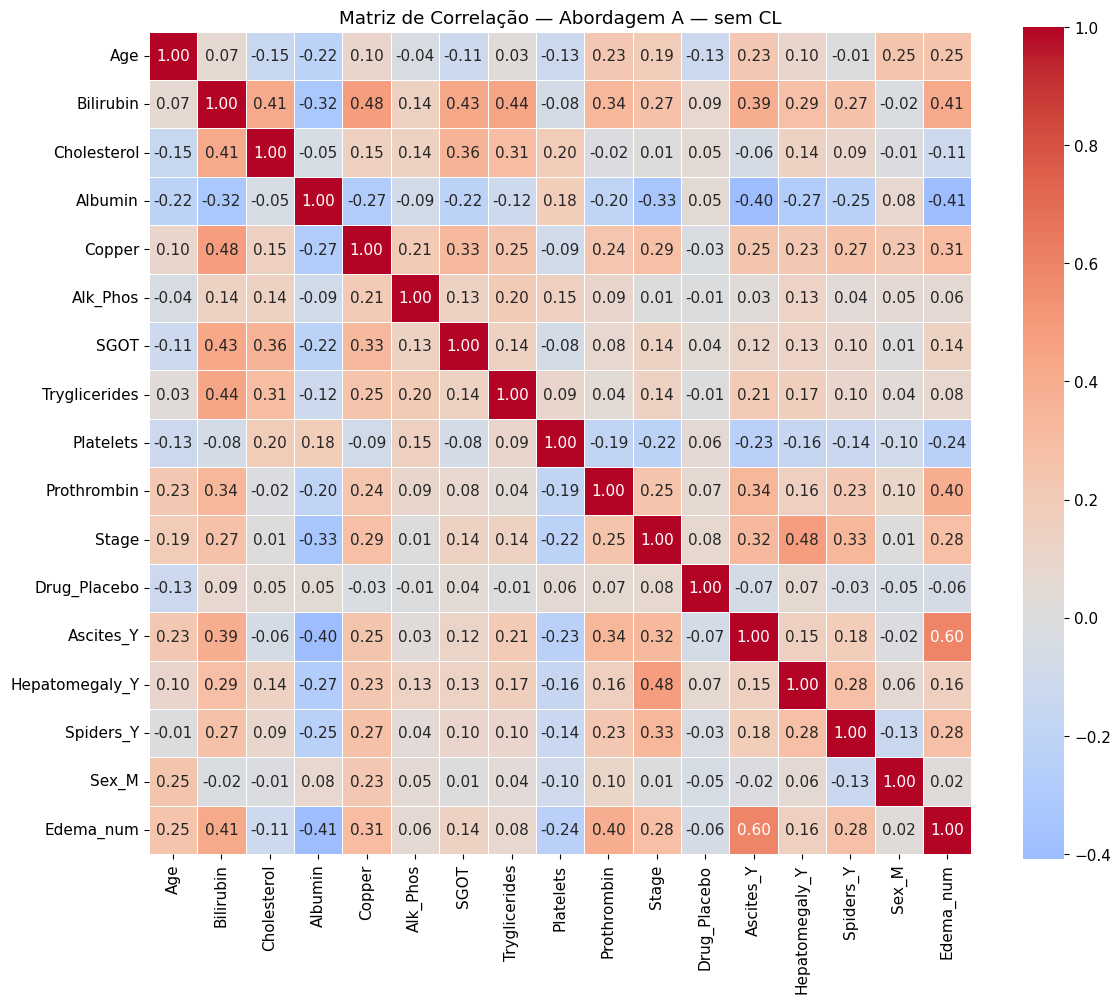


Pares que podem indicar multicolinearidade:

  Ascites_Y ↔ Edema_num
     r = 0.598 → Correlação POSITIVA forte


Correlação mais forte: Ascites_Y ↔ Edema_num (r = 0.598, Forte)

Resumo:
  Muito fortes (|r| ≥ 0.7): 0 par(es)
  Fortes (|r| ≥ 0.5): 1 par(es)
  Moderadas (0.3 ≤ |r| < 0.5): 20 par(es)

  Abordagem B — CL agrupado com C

=== 5º Passo: Separar Features do Target ===
            N_Days   Age  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos  \
Status_bin                                                                    
0           2177.0  47.0        1.0        298.5    3.610    58.5    1130.0   
1           1201.5  53.0        3.2        339.0    3.435   114.5    1788.5   

               SGOT  Tryglicerides  Platelets  Prothrombin  Stage  \
Status_bin                                                          
0            99.875          104.5      268.5         10.2    3.0   
1           134.850          120.0      235.0         11.0    3.0   

            Drug_Placebo 

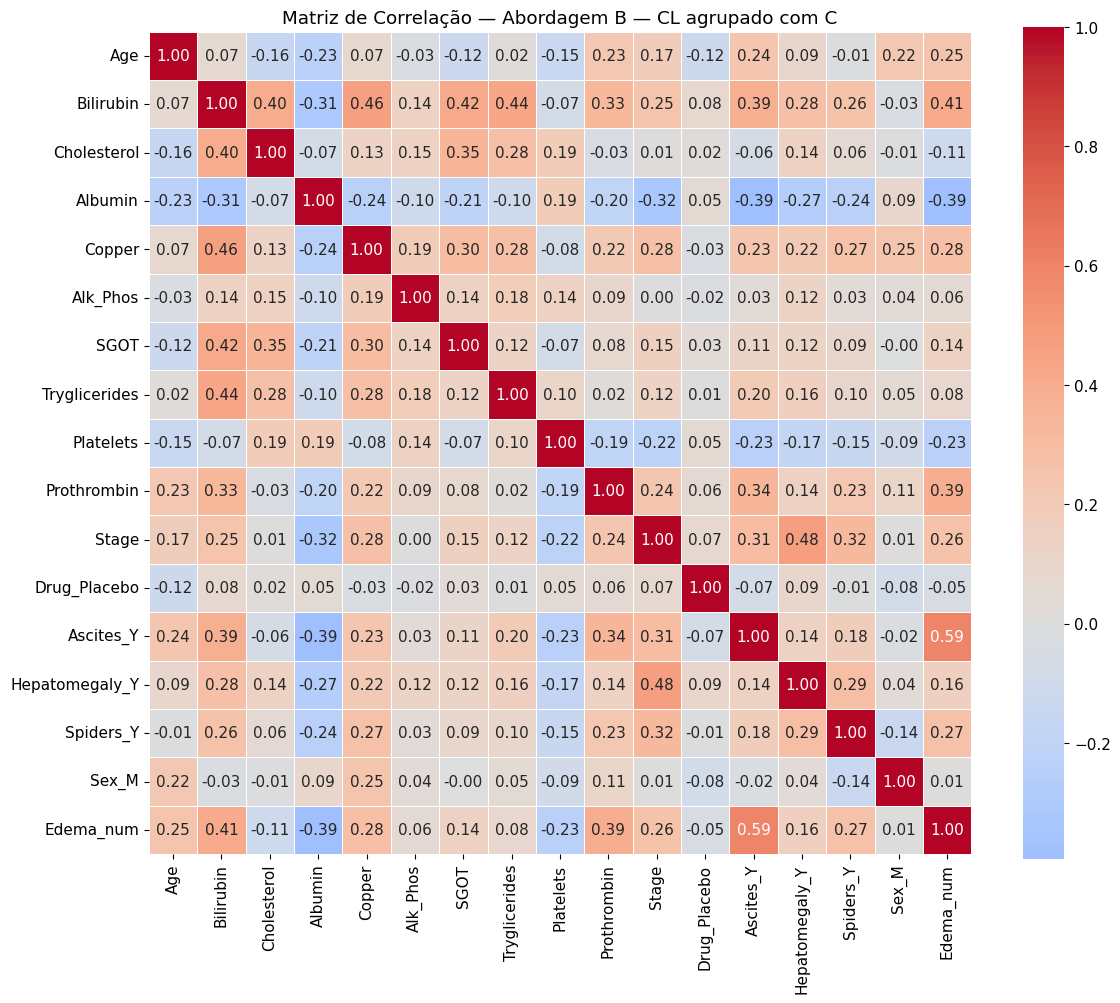


Pares que podem indicar multicolinearidade:

  Ascites_Y ↔ Edema_num
     r = 0.593 → Correlação POSITIVA forte


Correlação mais forte: Ascites_Y ↔ Edema_num (r = 0.593, Forte)

Resumo:
  Muito fortes (|r| ≥ 0.7): 0 par(es)
  Fortes (|r| ≥ 0.5): 1 par(es)
  Moderadas (0.3 ≤ |r| < 0.5): 18 par(es)


In [ ]:
# 5º e 6º passos: separar features do target e analisar correlações
# Define uma função reutilizável que executa os passos 5 e 6 para qualquer dataset
# Recebe dois argumentos: o dataset (db) e o nome da abordagem

def preparar_e_analisar(db, nome_abordagem):

    # Imprime um cabeçalho visual para separar os outputs das duas abordagens
    print(f"\n{'='*60}")
    print(f"  {nome_abordagem}")
    print(f"{'='*60}")

    # Cria uma cópia independente do dataset para não alterar o original
    # Sem .copy(), as alterações dentro da função afetariam database_A ou database_B
    db = db.copy()

    # 5º PASSO: Separar features do target
    print("\n=== 5º Passo: Separar Features do Target ===")

    # Agrupa por Status_bin (target) e mostra a mediana de cada variável numérica por grupo
    # Permite perceber quais as variáveis que mais distinguem os dois grupos
    # Remove ID antes de agrupar porque é apenas um identificador sem valor preditivo
    print(db.drop(columns=['ID']).groupby('Status_bin').median(numeric_only=True))

    # Remove N_Days porque é uma consequência do outcome (target) e não um preditor real, visto que o número de dias de seguimento só é conhecido após o evento ter ocorrido
    db.drop('N_Days', axis=1, inplace=True)

    # Separa o dataset em:
    # target (y): variável que queremos prever, ou seja, Status_bin (0 = censurado, 1 = morte)
    # db (X): todas as restantes variáveis que o modelo vai usar para prever (features)
    target = db['Status_bin']
    db.drop(['Status_bin', 'event', 'ID'], axis=1, inplace=True)

    print(f"\nFeatures: {db.columns.tolist()}")
    print(f"Distribuição do target:\n{target.value_counts()}")

    # 6º PASSO: Correlação entre features
    print("\n=== 6º Passo: Correlação entre Features ===")

    # Calcula a matriz de correlação de Pearson entre todas as variáveis numéricas
    # Cada célula contém o coeficiente r entre duas variáveis (de -1 a +1)
    db2 = db.corr()

    # Cria o heatmap da matriz de correlação
    plt.figure(figsize=(12, 10))
    sns.heatmap(db2,
                annot=True,       # Mostra os valores r em cada célula
                fmt='.2f',        # Formata com 2 casas decimais
                cmap='coolwarm',  # Azul = correlação negativa, vermelho = positiva
                center=0,         # Branco fica no centro (r = 0, sem correlação)
                square=True,      # Células quadradas para melhor leitura visual
                linewidths=0.5)   # Espaçamento visual entre células
    plt.title(f'Matriz de Correlação — {nome_abordagem}')
    plt.tight_layout()
    plt.show()

    # Constrói uma tabela com todos os pares únicos de variáveis e as suas correlações

    pairs = []
    for i in range(len(db2.columns)):
        for j in range(i + 1, len(db2.columns)):
            var1 = db2.columns[i]
            var2 = db2.columns[j]
            corr_val = db2.loc[var1, var2]    # Valor r entre as duas variáveis
            abs_corr_val = abs(corr_val)       # Valor absoluto para classificar a força
            if abs_corr_val > 0:
                # Classifica a força da correlação com base no valor absoluto de r
                if abs_corr_val >= 0.7:
                    strength = 'Muito forte'
                elif abs_corr_val >= 0.5:
                    strength = 'Forte'
                elif abs_corr_val >= 0.3:
                    strength = 'Moderada'
                else:
                    strength = 'Fraca'
                # Adiciona o par à lista com todas as suas informações
                pairs.append({
                    'Variável 1': var1,
                    'Variável 2': var2,
                    'Correlação (r)': corr_val,
                    '|r|': abs_corr_val,
                    'Força': strength
                })

    # Converte a lista num DataFrame e ordena do par mais correlacionado para o menos
    # reset_index(drop=True) renumera o índice após a ordenação
    tabela_corr = pd.DataFrame(pairs).sort_values(by='|r|', ascending=False).reset_index(drop=True)

    # Filtra os pares com correlação forte (|r| ≥ 0.5) que podem indicar multicolinearidade (informação redundante para o modelo)
    fortes = tabela_corr[tabela_corr['|r|'] >= 0.5]
    if len(fortes) > 0:
        print("\nPares que podem indicar multicolinearidade:\n")
        for _, linha in fortes.iterrows():
            # Determina a direção da correlação para facilitar a interpretação
            direcao = "POSITIVA" if linha['Correlação (r)'] > 0 else "NEGATIVA"
            print(f"  {linha['Variável 1']} ↔ {linha['Variável 2']}")
            print(f"     r = {linha['Correlação (r)']:.3f} → Correlação {direcao} forte\n")
    else:
        print("\nNenhum par com correlação forte (|r| ≥ 0.5) encontrado.")

    # Resumo quantitativo dos pares por nível de força
    corr_max = tabela_corr.iloc[0]  # Primeiro elemento = correlação mais forte (já ordenado)
    severos = len(tabela_corr[tabela_corr['|r|'] >= 0.7])
    fortes_count = len(tabela_corr[tabela_corr['|r|'] >= 0.5])
    moderados = len(tabela_corr[(tabela_corr['|r|'] >= 0.3) & (tabela_corr['|r|'] < 0.5)])

    print(f"\nCorrelação mais forte: {corr_max['Variável 1']} ↔ {corr_max['Variável 2']} (r = {corr_max['Correlação (r)']:.3f}, {corr_max['Força']})")
    print(f"\nResumo:")
    print(f"  Muito fortes (|r| ≥ 0.7): {severos} par(es)")
    print(f"  Fortes (|r| ≥ 0.5): {fortes_count} par(es)")
    print(f"  Moderadas (0.3 ≤ |r| < 0.5): {moderados} par(es)")

    # Devolve o dataset de features (X) e o target (y) para usar nos modelos
    return db, target


# Chama a função para cada abordagem
# Os resultados ficam guardados em variáveis separadas para usar nos modelos
X_A, y_A = preparar_e_analisar(database_A, "Abordagem A — sem CL")  # Dataset sem os 25 CL
X_B, y_B = preparar_e_analisar(database_B, "Abordagem B — CL agrupado com C")  # Dataset completo

In [ ]:
# 7º passo: dividir os dados em treino e teste


# train_test_split() recebe 4 argumentos principais:
# 1º e 2º: as features (X) e o target (y) a dividir
# test_size=0.2: 20% dos dados vão para teste, 80% para treino
# random_state=42: semente aleatória que garante que a divisão é sempre igual, ou seja, garante reprodutibilidade
# stratify=y: garante que a proporção de 0s e 1s no target é mantida tanto no treino como no teste (+ importante em datasets desequilibrados)

#Abordagem A (sem CL)
X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A,           # Features da Abordagem A
    y_A,           # Target da Abordagem A
    test_size=0.2,
    random_state=42,
    stratify=y_A   # Mantém a proporção de mortes/censurados em treino e teste
)

# Confirmação da dimensão dos conjuntos criados para a Abordagem A
# .shape devolve uma tupla (nº de linhas, nº de colunas)
print("=== Abordagem A — sem CL ===")
print(f"Treino: {X_A_train.shape[0]} observações ({X_A_train.shape[0]/len(X_A)*100:.0f}%)")
print(f"Teste:  {X_A_test.shape[0]} observações ({X_A_test.shape[0]/len(X_A)*100:.0f}%)")

# Verifica se a proporção do target foi mantida em treino e teste (stratify)
# value_counts(normalize=True) devolve proporções em vez de contagens
print("\nProporção do target no treino (Abordagem A):")
print(y_A_train.value_counts(normalize=True).round(2))
print("Proporção do target no teste (Abordagem A):")
print(y_A_test.value_counts(normalize=True).round(2))

# Abordagem B (CL agrupado com C)
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B,           # Features da Abordagem B
    y_B,           # Target da Abordagem B
    test_size=0.2,
    random_state=42,
    stratify=y_B
)

print("\n=== Abordagem B — CL agrupado com C ===")
print(f"Treino: {X_B_train.shape[0]} observações ({X_B_train.shape[0]/len(X_B)*100:.0f}%)")
print(f"Teste:  {X_B_test.shape[0]} observações ({X_B_test.shape[0]/len(X_B)*100:.0f}%)")

print("\nProporção do target no treino (Abordagem B):")
print(y_B_train.value_counts(normalize=True).round(2))
print("Proporção do target no teste (Abordagem B):")
print(y_B_test.value_counts(normalize=True).round(2))

=== Abordagem A — sem CL ===
Treino: 212 observações (80%)
Teste:  54 observações (20%)

Proporção do target no treino (Abordagem A):
Status_bin
0    0.57
1    0.43
Name: proportion, dtype: float64
Proporção do target no teste (Abordagem A):
Status_bin
0    0.57
1    0.43
Name: proportion, dtype: float64

=== Abordagem B — CL agrupado com C ===
Treino: 227 observações (80%)
Teste:  57 observações (20%)

Proporção do target no treino (Abordagem B):
Status_bin
0    0.6
1    0.4
Name: proportion, dtype: float64
Proporção do target no teste (Abordagem B):
Status_bin
0    0.6
1    0.4
Name: proportion, dtype: float64


In [ ]:
# 8º passo: normalização dos dados

# Importa o StandardScaler que estandardiza as variáveis numéricas:
# Para cada variável, subtrai a média e divide pelo desvio padrão
# O resultado é que cada variável fica com média = 0 e desvio padrão = 1
from sklearn.preprocessing import StandardScaler

# Identifica as colunas binárias que não devem ser normalizadas
binary_cols = ['Drug_Placebo', 'Ascites_Y', 'Hepatomegaly_Y', 'Spiders_Y', 'Sex_M']

# Identifica as colunas numéricas contínuas e ordinais que devem ser normalizadas (todas as colunas que não são binárias)
cols_to_scale = [col for col in X_A_train.columns if col not in binary_cols]
print(f"Colunas a normalizar: {cols_to_scale}")
print(f"Colunas a manter sem normalização: {binary_cols}")

#Abordagem A
scaler_A = StandardScaler()

# Cria cópias dos datasets para não alterar os originais
X_A_train_scaled = X_A_train.copy()
X_A_test_scaled = X_A_test.copy()

# fit_transform() no conjunto de treino:
# fit(): aprende a média e desvio padrão de cada variável apenas a partir do treino
# transform(): aplica a estandardização aos dados de treino
# Nunca se faz fit() nos dados de teste porque isso causaria data leakage
X_A_train_scaled[cols_to_scale] = scaler_A.fit_transform(X_A_train[cols_to_scale])

# transform() no conjunto de teste:
# Usa os parâmetros (média e desvio padrão) aprendidos no treino para transformar o teste
# Desta forma o teste é tratado como se fossem dados novos e desconhecidos
X_A_test_scaled[cols_to_scale] = scaler_A.transform(X_A_test[cols_to_scale])

# Confirmação visual da normalização para a Abordagem A
print("\n=== Abordagem A — verificação da normalização ===")
print("Médias no treino (devem ser ~0):")
print(X_A_train_scaled[cols_to_scale].mean().round(2))
print("\nDesvios padrão no treino (devem ser ~1):")
print(X_A_train_scaled[cols_to_scale].std().round(2))

# Abordagem B
scaler_B = StandardScaler()

X_B_train_scaled = X_B_train.copy()
X_B_test_scaled = X_B_test.copy()

# Mesmo processo: fit_transform() no treino, transform() no teste
X_B_train_scaled[cols_to_scale] = scaler_B.fit_transform(X_B_train[cols_to_scale])
X_B_test_scaled[cols_to_scale] = scaler_B.transform(X_B_test[cols_to_scale])

print("\n=== Abordagem B — verificação da normalização ===")
print("Médias no treino (devem ser ~0):")
print(X_B_train_scaled[cols_to_scale].mean().round(2))
print("\nDesvios padrão no treino (devem ser ~1):")
print(X_B_train_scaled[cols_to_scale].std().round(2))

Colunas a normalizar: ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Edema_num']
Colunas a manter sem normalização: ['Drug_Placebo', 'Ascites_Y', 'Hepatomegaly_Y', 'Spiders_Y', 'Sex_M']

=== Abordagem A — verificação da normalização ===
Médias no treino (devem ser ~0):
Age             -0.0
Bilirubin        0.0
Cholesterol     -0.0
Albumin          0.0
Copper           0.0
Alk_Phos         0.0
SGOT            -0.0
Tryglicerides    0.0
Platelets       -0.0
Prothrombin     -0.0
Stage           -0.0
Edema_num       -0.0
dtype: float64

Desvios padrão no treino (devem ser ~1):
Age              1.0
Bilirubin        1.0
Cholesterol      1.0
Albumin          1.0
Copper           1.0
Alk_Phos         1.0
SGOT             1.0
Tryglicerides    1.0
Platelets        1.0
Prothrombin      1.0
Stage            1.0
Edema_num        1.0
dtype: float64

=== Abordagem B — verificação da normalização ===
Médias no treino (


  Abordagem A — sem CL

--- Logistic Regression ---
              precision    recall  f1-score   support

   Censurado       0.87      0.87      0.87        31
       Morte       0.83      0.83      0.83        23

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54

AUC-ROC: 0.906


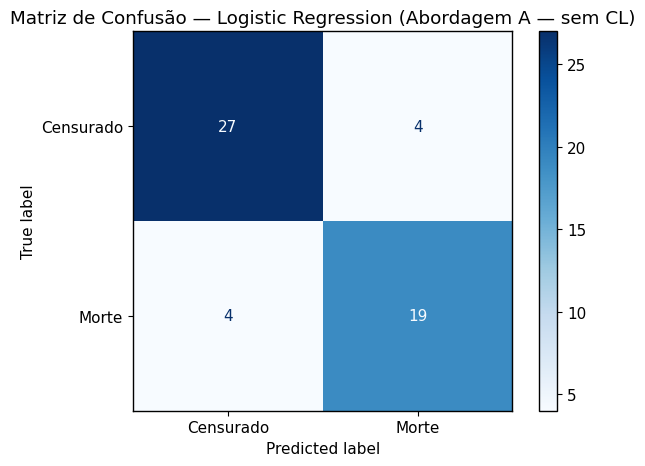

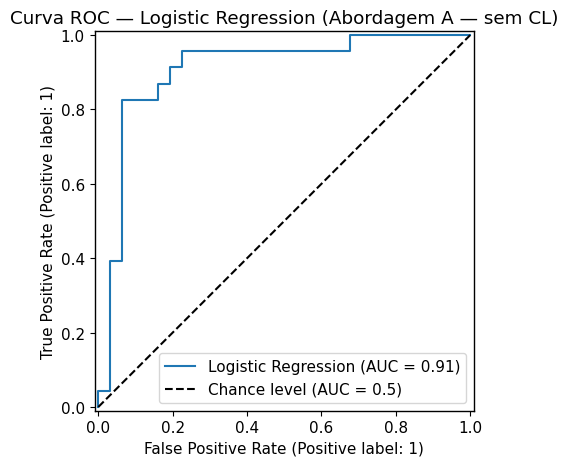


--- LDA ---
              precision    recall  f1-score   support

   Censurado       0.90      0.87      0.89        31
       Morte       0.83      0.87      0.85        23

    accuracy                           0.87        54
   macro avg       0.87      0.87      0.87        54
weighted avg       0.87      0.87      0.87        54

AUC-ROC: 0.903


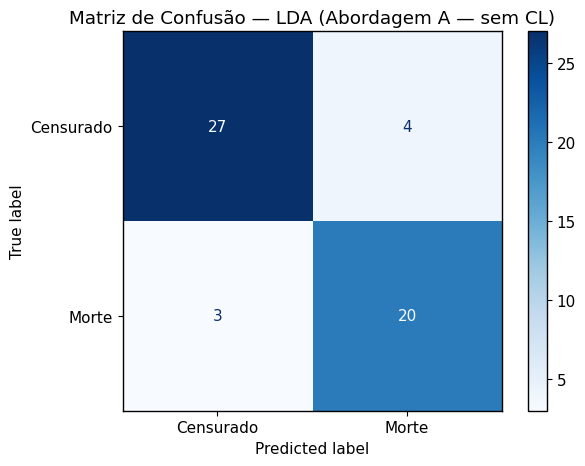

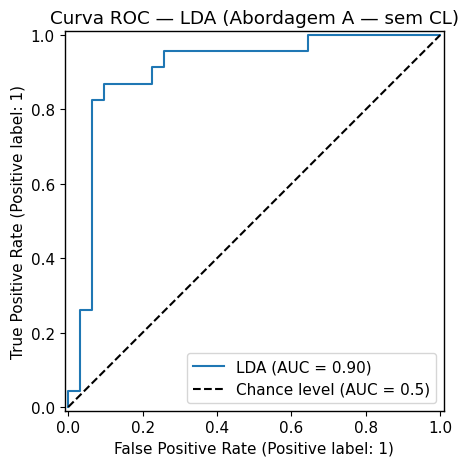


--- Naive Bayes ---
              precision    recall  f1-score   support

   Censurado       0.81      0.94      0.87        31
       Morte       0.89      0.70      0.78        23

    accuracy                           0.83        54
   macro avg       0.85      0.82      0.82        54
weighted avg       0.84      0.83      0.83        54

AUC-ROC: 0.887


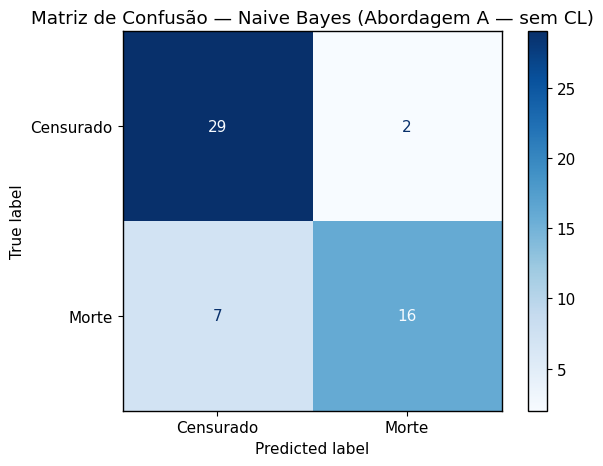

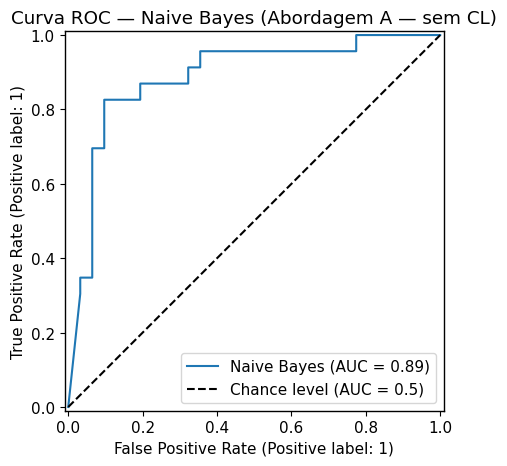


--- Random Forest ---
              precision    recall  f1-score   support

   Censurado       0.86      0.81      0.83        31
       Morte       0.76      0.83      0.79        23

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54

AUC-ROC: 0.877


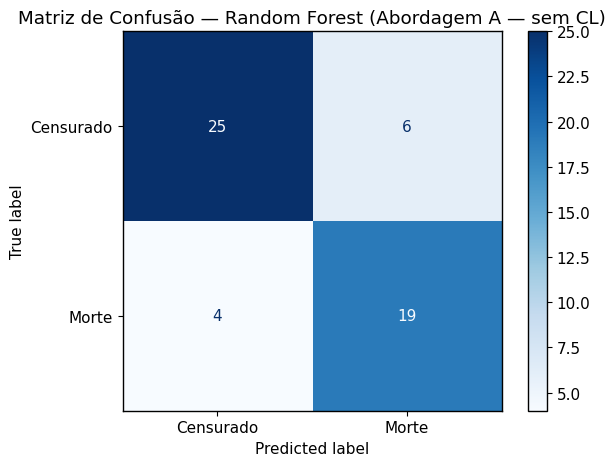

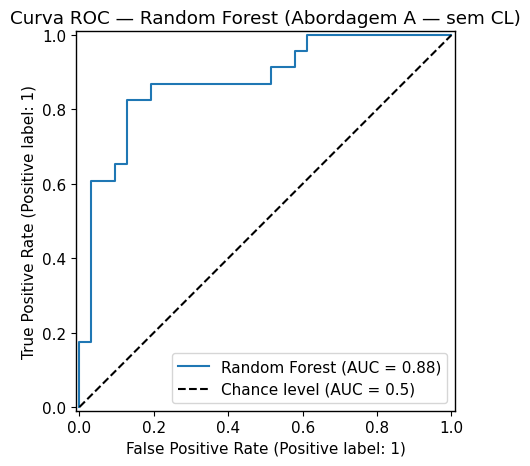


--- AdaBoost ---
              precision    recall  f1-score   support

   Censurado       0.88      0.90      0.89        31
       Morte       0.86      0.83      0.84        23

    accuracy                           0.87        54
   macro avg       0.87      0.86      0.87        54
weighted avg       0.87      0.87      0.87        54

AUC-ROC: 0.892


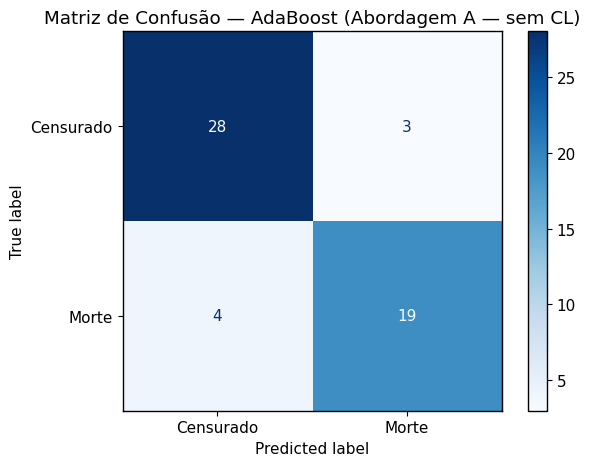

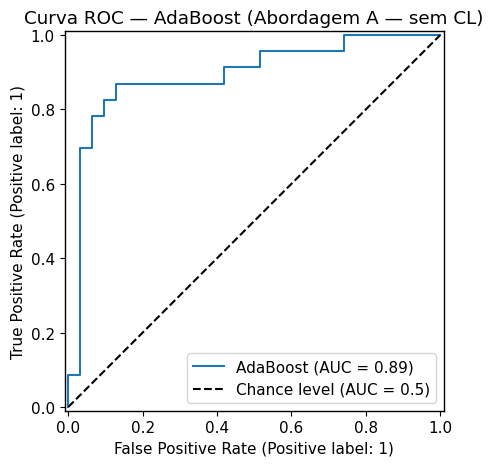


--- SVM ---
              precision    recall  f1-score   support

   Censurado       0.86      0.81      0.83        31
       Morte       0.76      0.83      0.79        23

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54

AUC-ROC: 0.893


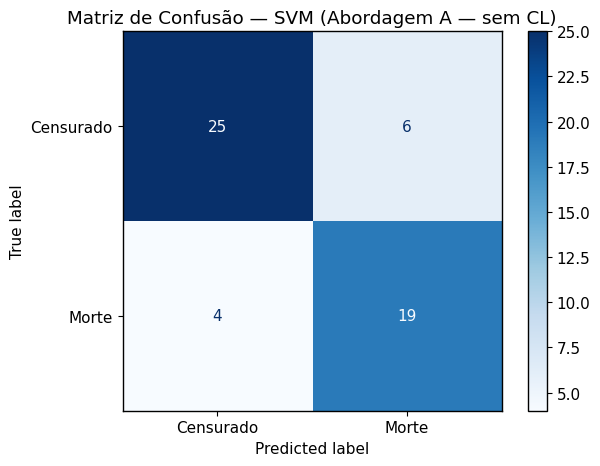

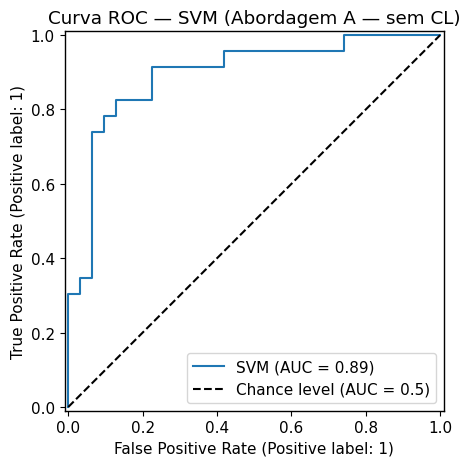


  Comparação de Modelos — Abordagem A — sem CL
             Modelo  AUC-ROC  Precision (Morte)  Recall (Morte)  F1 (Morte)  Accuracy
Logistic Regression    0.906              0.826           0.826       0.826     0.852
                LDA    0.903              0.833           0.870       0.851     0.870
                SVM    0.893              0.760           0.826       0.792     0.815
           AdaBoost    0.892              0.864           0.826       0.844     0.870
        Naive Bayes    0.887              0.889           0.696       0.780     0.833
      Random Forest    0.877              0.760           0.826       0.792     0.815

  Abordagem B — CL agrupado com C

--- Logistic Regression ---
              precision    recall  f1-score   support

   Censurado       0.76      0.76      0.76        34
       Morte       0.65      0.65      0.65        23

    accuracy                           0.72        57
   macro avg       0.71      0.71      0.71        57
weighted avg  

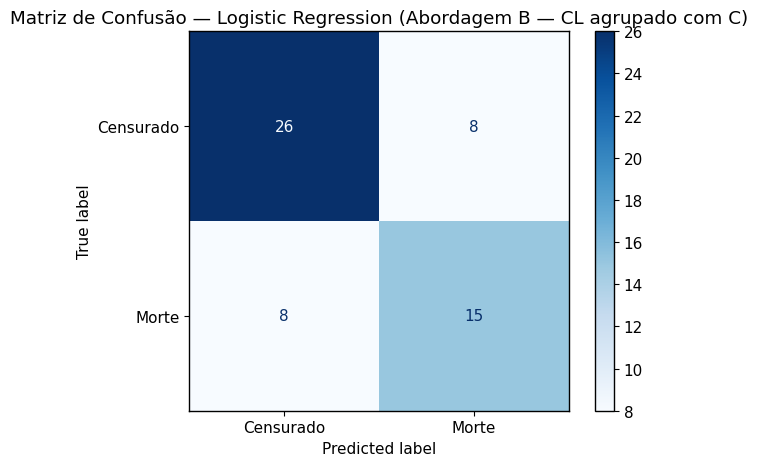

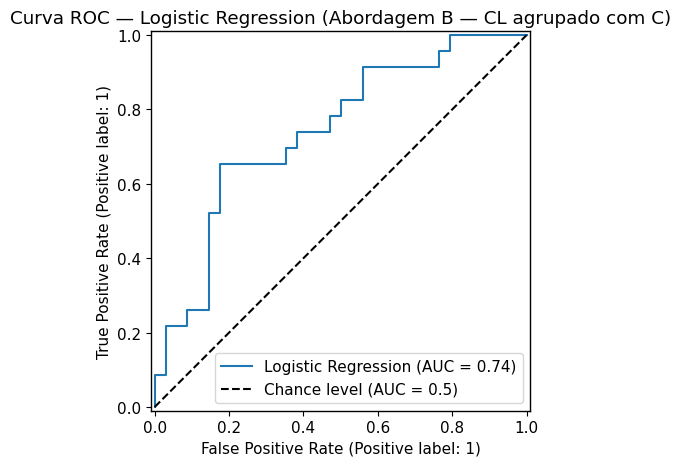


--- LDA ---
              precision    recall  f1-score   support

   Censurado       0.76      0.76      0.76        34
       Morte       0.65      0.65      0.65        23

    accuracy                           0.72        57
   macro avg       0.71      0.71      0.71        57
weighted avg       0.72      0.72      0.72        57

AUC-ROC: 0.752


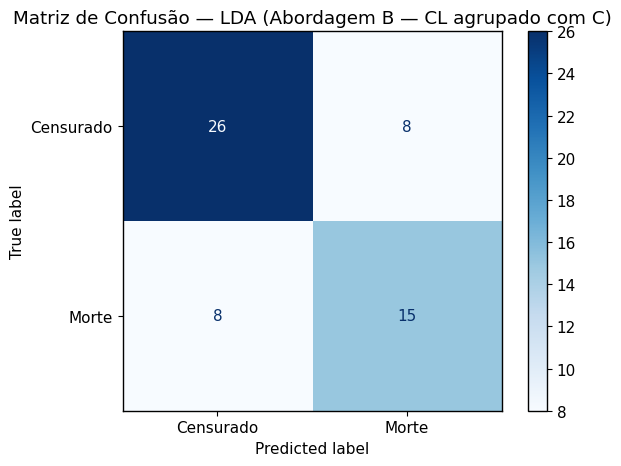

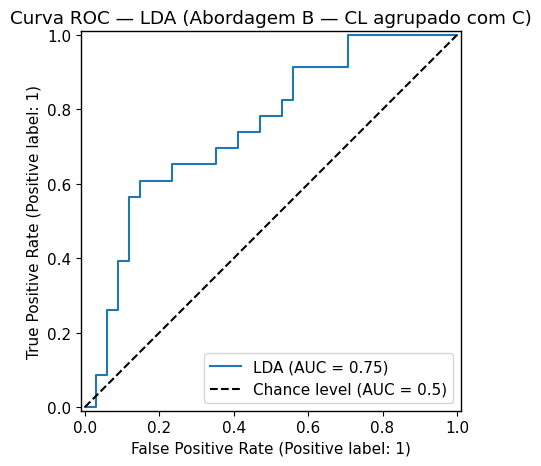


--- Naive Bayes ---
              precision    recall  f1-score   support

   Censurado       0.76      0.82      0.79        34
       Morte       0.70      0.61      0.65        23

    accuracy                           0.74        57
   macro avg       0.73      0.72      0.72        57
weighted avg       0.73      0.74      0.73        57

AUC-ROC: 0.744


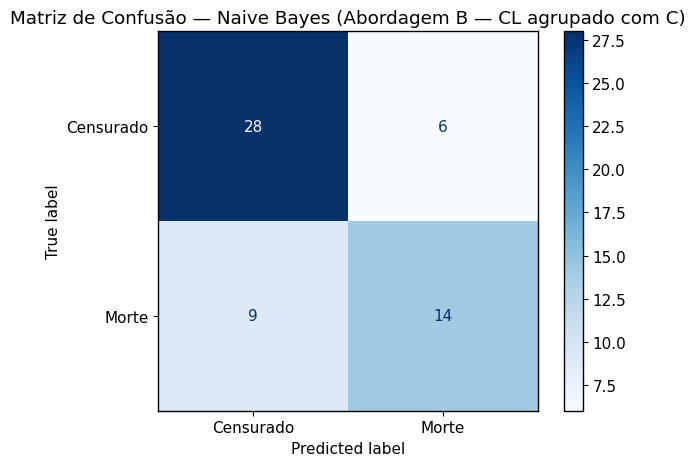

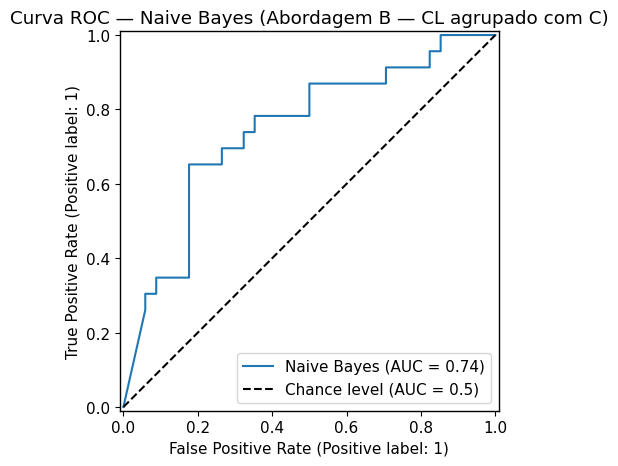


--- Random Forest ---
              precision    recall  f1-score   support

   Censurado       0.78      0.85      0.82        34
       Morte       0.75      0.65      0.70        23

    accuracy                           0.77        57
   macro avg       0.77      0.75      0.76        57
weighted avg       0.77      0.77      0.77        57

AUC-ROC: 0.748


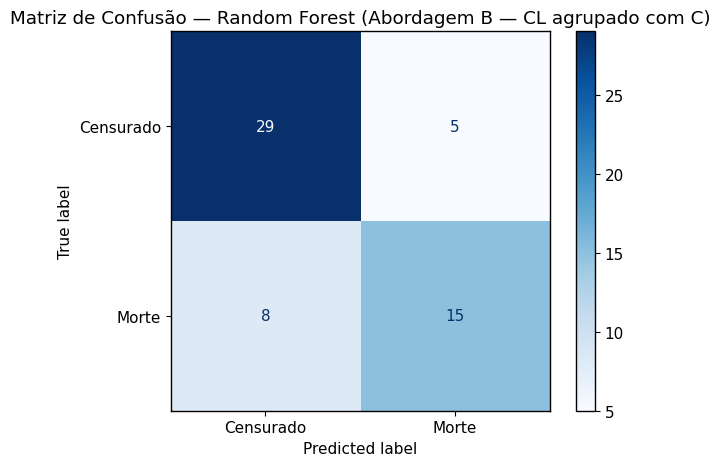

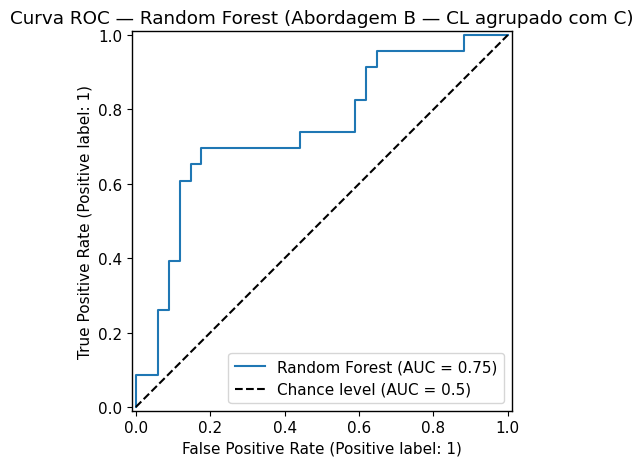


--- AdaBoost ---
              precision    recall  f1-score   support

   Censurado       0.74      0.76      0.75        34
       Morte       0.64      0.61      0.62        23

    accuracy                           0.70        57
   macro avg       0.69      0.69      0.69        57
weighted avg       0.70      0.70      0.70        57

AUC-ROC: 0.747


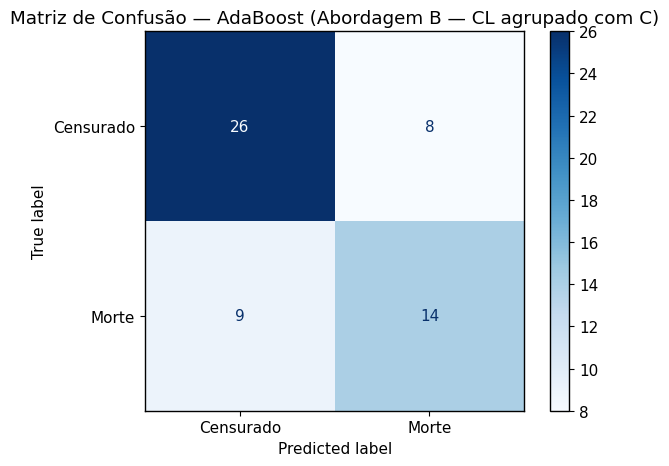

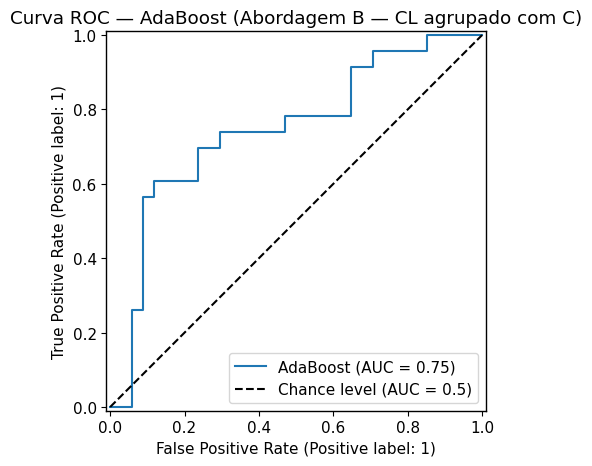


--- SVM ---
              precision    recall  f1-score   support

   Censurado       0.79      0.79      0.79        34
       Morte       0.70      0.70      0.70        23

    accuracy                           0.75        57
   macro avg       0.74      0.74      0.74        57
weighted avg       0.75      0.75      0.75        57

AUC-ROC: 0.733


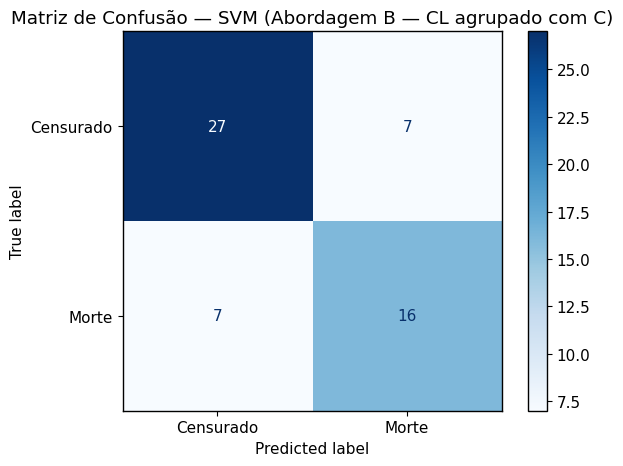

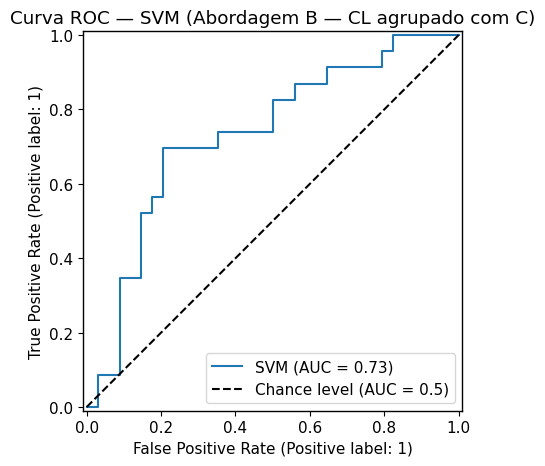


  Comparação de Modelos — Abordagem B — CL agrupado com C
             Modelo  AUC-ROC  Precision (Morte)  Recall (Morte)  F1 (Morte)  Accuracy
                LDA    0.752              0.652           0.652       0.652     0.719
      Random Forest    0.748              0.750           0.652       0.698     0.772
           AdaBoost    0.747              0.636           0.609       0.622     0.702
        Naive Bayes    0.744              0.700           0.609       0.651     0.737
Logistic Regression    0.740              0.652           0.652       0.652     0.719
                SVM    0.733              0.696           0.696       0.696     0.754

=== Comparação Final entre Abordagens ===

Abordagem A:
             Modelo  AUC-ROC  Precision (Morte)  Recall (Morte)  F1 (Morte)  Accuracy
Logistic Regression    0.906              0.826           0.826       0.826     0.852
                LDA    0.903              0.833           0.870       0.851     0.870
                SVM    0

In [ ]:
import sklearn
# 9º passo: construção e avaliação dos modelos

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay)

# Define os 6 modelos com os seus parâmetros
# Cada entrada do dicionário contém:
# 'model': a instância do algoritmo com os seus hiperparâmetros
# 'scaled': se o modelo requer dados normalizados (True) ou não (False)
models = {

    # Regressão Logística com regularização L2 (default) e solver lbfgs
    # max_iter=1000 aumenta o número máximo de iterações para garantir convergência em datasets com muitas features
    # C=1.0 (default): parâmetro de regularização inverso — maior C = menos regularização
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'scaled': True  # Sensível à escala, por isso usa dados normalizados
    },

    # LDA: encontra a combinação linear de features que maximiza a separação entre classes
    # Assume distribuição Normal multivariada e matrizes de covariância iguais entre classes
    # Particularmente adequado para datasets pequenos por ser paramétrico
    'LDA': {
        'model': LinearDiscriminantAnalysis(),
        'scaled': True  # Beneficia do uso de dados normalizados
    },

    # Naive Bayes Gaussiano: modelo probabilístico que aplica o Teorema de Bayes, assumindo independência condicional entre features e distribuição Normal por classe
    # var_smoothing=1e-9 (default): adiciona pequena variância para estabilidade numérica
    'Naive Bayes': {
        'model': GaussianNB(),
        'scaled': False  # Não necessita de normalização
    },

    # Random Forest: ensemble de árvores de decisão treinadas por bagging
    # n_estimators=500: número de árvores — mais árvores = estimativas mais estáveis
    # min_samples_leaf=5: mínimo de 5 observações por folha para evitar overfitting em datasets pequenos
    # max_features='sqrt' (default): usa raiz quadrada do nº de features em cada nó
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=500, min_samples_leaf=5, random_state=42),
        'scaled': False  # Não necessita de normalização
    },

    # AdaBoost: ensemble sequencial que treina árvores simples (stumps) iterativamente
    # Cada iteração dá mais peso aos casos mal classificados pelo modelo anterior
    # n_estimators=200: número de iterações do boosting
    # learning_rate=0.1: controla a contribuição de cada modelo — valores baixos
    # requerem mais estimadores mas tendem a generalizar melhor
    'AdaBoost': {
        'model': AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
        'scaled': False  # Não necessita de normalização
    },

    # SVM com kernel RBF: encontra o hiperplano de margem máxima entre classes num espaço de alta dimensão através do kernel trick
    # kernel='rbf': Radial Basis Function — captura relações não-lineares
    # C=1.0 (default): controla o trade-off entre maximizar margem e minimizar erros
    # probability=True: permite obter probabilidades calibradas para calcular AUC-ROC
    # gamma='scale' (default): calcula gamma como 1/(n_features * X.var())
    'SVM': {
        'model': SVC(kernel='rbf', probability=True, random_state=42),
        'scaled': True  # Muito sensível à escala, por isso, requer normalização
    }
}


# Função que treina e avalia um conjunto de modelos para uma abordagem
# Argumentos:
# X_train, X_test: dados de treino e teste não normalizados
# X_train_scaled, X_test_scaled: dados de treino e teste normalizados
# y_train, y_test: targets de treino e teste
# nome_abordagem: string para identificar os outputs visualmente
def treinar_e_avaliar(X_train, X_test, X_train_scaled, X_test_scaled,
                      y_train, y_test, nome_abordagem):

    # Cabeçalho visual para separar os outputs das diferentes abordagens
    print(f"\n{'='*60}")
    print(f"  {nome_abordagem}")
    print(f"{'='*60}")

    # Lista para acumular os resultados de cada modelo para a tabela comparativa final
    resultados = []

    for nome_modelo, config in models.items():

        print(f"\n--- {nome_modelo} ---")

        # Seleciona os dados normalizados ou não consoante a sensibilidade do modelo à escala
        if config['scaled']:
            X_tr = X_train_scaled
            X_te = X_test_scaled
        else:
            X_tr = X_train
            X_te = X_test

        # .fit() treina o modelo ajustando os seus parâmetros internos aos dados de treino
        model = config['model']
        model.fit(X_tr, y_train)

        # .predict() gera previsões de classe (0 = censurado, 1 = morte) para o conjunto de teste
        y_pred = model.predict(X_te)

        # .predict_proba() gera probabilidades de pertencer a cada classe
        # [:, 1] seleciona apenas a probabilidade da classe positiva (morte = 1)
        # Necessário para calcular o AUC-ROC
        y_prob = model.predict_proba(X_te)[:, 1]

        #Avaliação dos modelos

        # AUC-ROC: área sob a curva ROC
        # Mede a capacidade discriminativa do modelo independentemente do limiar de decisão
        # 0.5 = classificador aleatório; 1.0 = classificador perfeito
        auc = roc_auc_score(y_test, y_prob)

        # classification_report: relatório completo com métricas por classe
        # Precision: proporção de previsões de morte que eram realmente morte (VPP)
        # Recall: proporção de mortes reais que o modelo identificou corretamente (Sensibilidade)
        # F1-score: média harmónica entre precision e recall
        # Support: número de observações reais de cada classe no conjunto de teste
        report = classification_report(y_test, y_pred, target_names=['Censurado', 'Morte'])
        print(report)
        print(f"AUC-ROC: {auc:.3f}")

        # Matriz de confusão:
        # Verdadeiros Negativos (VN): censurados corretamente classificados
        # Falsos Positivos (FP): censurados classificados como morte
        # Falsos Negativos (FN): mortes classificadas como censurado (erro mais grave clinicamente)
        # Verdadeiros Positivos (VP): mortes corretamente classificadas
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Censurado', 'Morte'])
        disp.plot(cmap='Blues')
        plt.title(f'Matriz de Confusão — {nome_modelo} ({nome_abordagem})')
        plt.tight_layout()
        plt.show()

        # Curva ROC: representa o trade-off entre sensibilidade (eixo y) e
        # 1-especificidade (eixo x) para todos os limiares de decisão possíveis
        # plot_chance_level=True: adiciona a linha diagonal (AUC = 0.5, classificador aleatório)
        RocCurveDisplay.from_predictions(y_test, y_prob,
                                          name=nome_modelo,
                                          plot_chance_level=True)
        plt.title(f'Curva ROC — {nome_modelo} ({nome_abordagem})')
        plt.tight_layout()
        plt.show()

        # Guarda os resultados para a tabela comparativa
        # output_dict=True devolve o classification_report como dicionário para aceder aos valores
        report_dict = classification_report(y_test, y_pred, target_names=['Censurado', 'Morte'], output_dict=True)
        resultados.append({
            'Modelo': nome_modelo,
            'AUC-ROC': round(auc, 3),
            'Precision (Morte)': round(report_dict['Morte']['precision'], 3),
            'Recall (Morte)': round(report_dict['Morte']['recall'], 3),
            'F1 (Morte)': round(report_dict['Morte']['f1-score'], 3),
            'Accuracy': round(report_dict['accuracy'], 3)
        })

    # Tabela comparativa final ordenada por AUC-ROC decrescente
    print(f"\n{'='*60}")
    print(f"  Comparação de Modelos — {nome_abordagem}")
    print(f"{'='*60}")
    df_resultados = pd.DataFrame(resultados).sort_values('AUC-ROC', ascending=False)
    print(df_resultados.to_string(index=False))

    return df_resultados


# Corre a função para cada abordagem
# Os resultados ficam guardados para comparação posterior
resultados_A = treinar_e_avaliar(
    X_A_train, X_A_test, X_A_train_scaled, X_A_test_scaled,
    y_A_train, y_A_test,
    "Abordagem A — sem CL"
)

resultados_B = treinar_e_avaliar(
    X_B_train, X_B_test, X_B_train_scaled, X_B_test_scaled,
    y_B_train, y_B_test,
    "Abordagem B — CL agrupado com C"
)

# Comparação final entre as duas abordagens
print("\n=== Comparação Final entre Abordagens ===")
print("\nAbordagem A:")
print(resultados_A.to_string(index=False))
print("\nAbordagem B:")
print(resultados_B.to_string(index=False))

=== Scores combinados por feature ===
       Feature  Score F (norm)  MI (norm)  RF (norm)  Score Médio
     Bilirubin           0.821      1.000      1.000        0.940
        Copper           1.000      0.955      0.782        0.912
   Prothrombin           0.543      0.638      0.552        0.578
         Stage           0.512      0.741      0.112        0.455
          SGOT           0.359      0.416      0.365        0.380
     Ascites_Y           0.471      0.575      0.061        0.369
       Albumin           0.318      0.443      0.251        0.338
      Alk_Phos           0.261      0.447      0.268        0.325
Hepatomegaly_Y           0.324      0.532      0.067        0.308
           Age           0.234      0.195      0.257        0.229
     Edema_num           0.399      0.166      0.044        0.203
     Spiders_Y           0.274      0.246      0.046        0.189
     Platelets           0.077      0.144      0.187        0.136
         Sex_M           0.168      0.

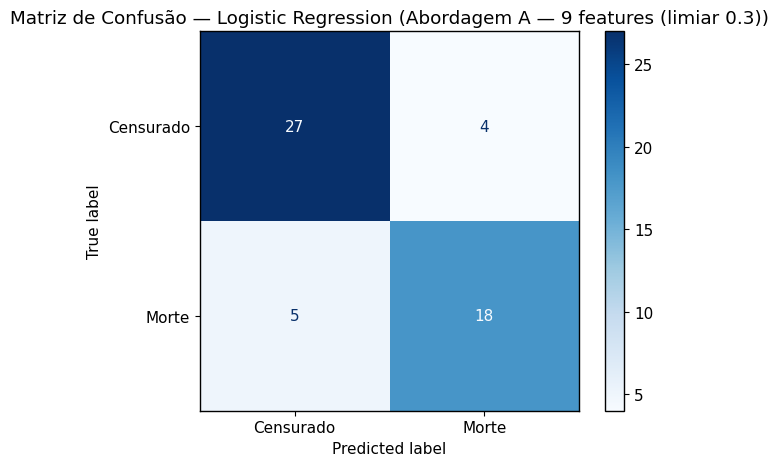

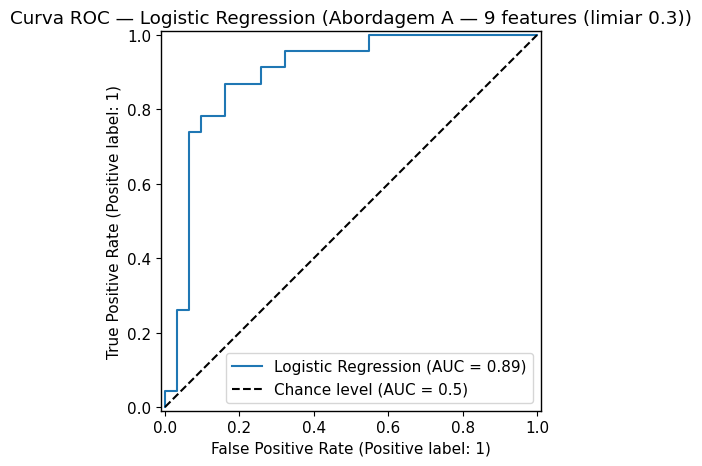


--- LDA ---
              precision    recall  f1-score   support

   Censurado       0.84      0.87      0.86        31
       Morte       0.82      0.78      0.80        23

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54

AUC-ROC: 0.893


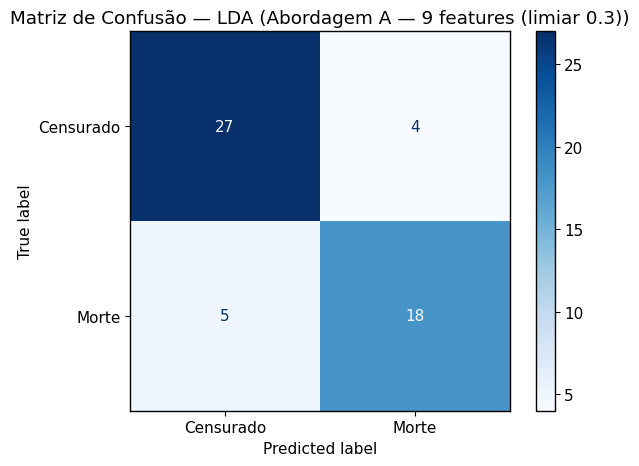

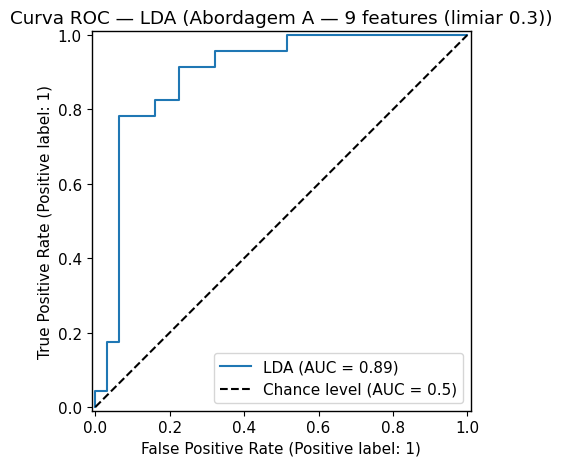


--- Naive Bayes ---
              precision    recall  f1-score   support

   Censurado       0.83      0.94      0.88        31
       Morte       0.89      0.74      0.81        23

    accuracy                           0.85        54
   macro avg       0.86      0.84      0.84        54
weighted avg       0.86      0.85      0.85        54

AUC-ROC: 0.881


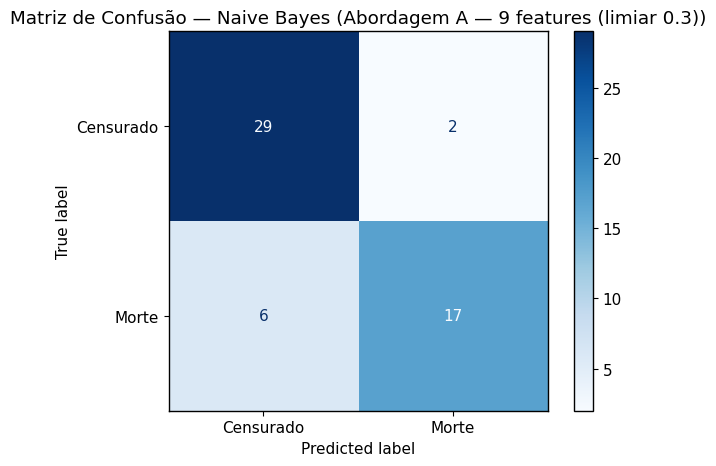

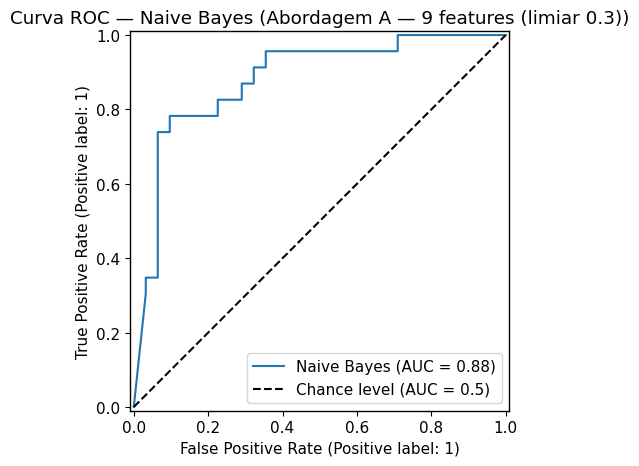


--- Random Forest ---
              precision    recall  f1-score   support

   Censurado       0.90      0.84      0.87        31
       Morte       0.80      0.87      0.83        23

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54

AUC-ROC: 0.882


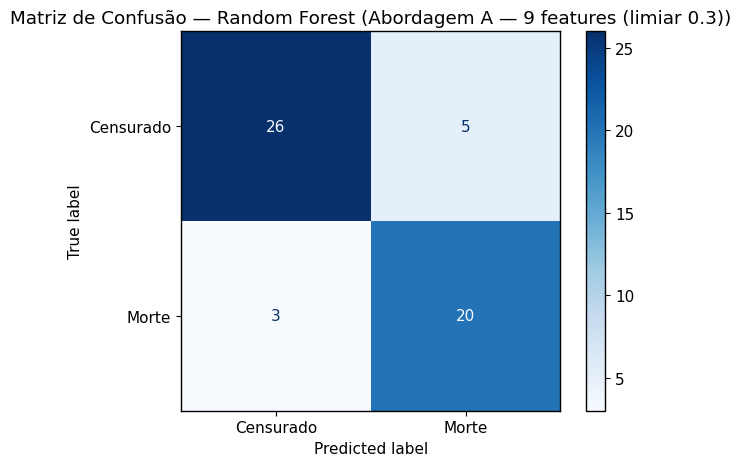

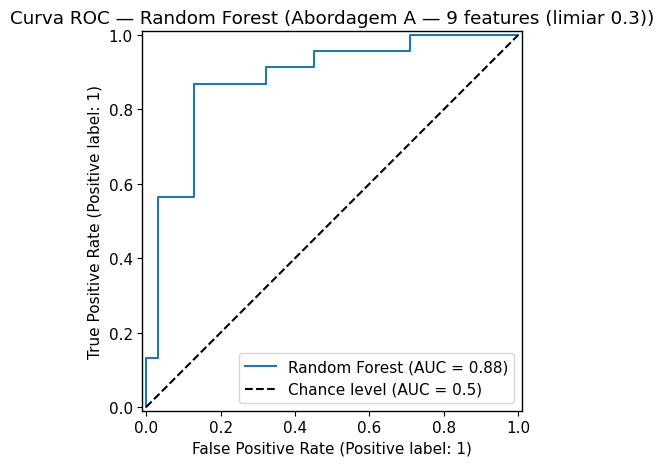


--- AdaBoost ---
              precision    recall  f1-score   support

   Censurado       0.90      0.84      0.87        31
       Morte       0.80      0.87      0.83        23

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54

AUC-ROC: 0.884


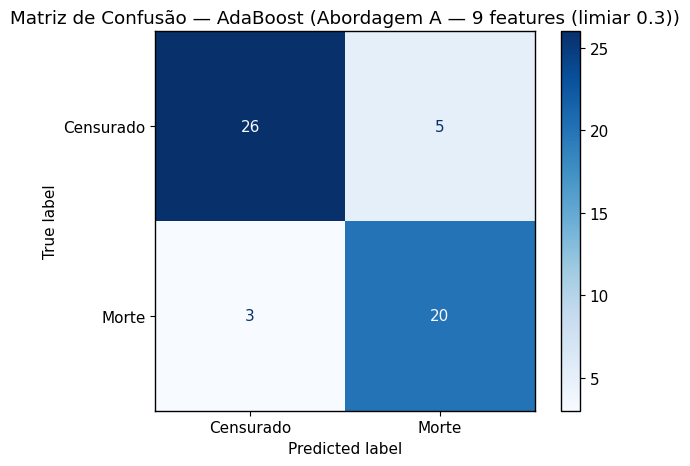

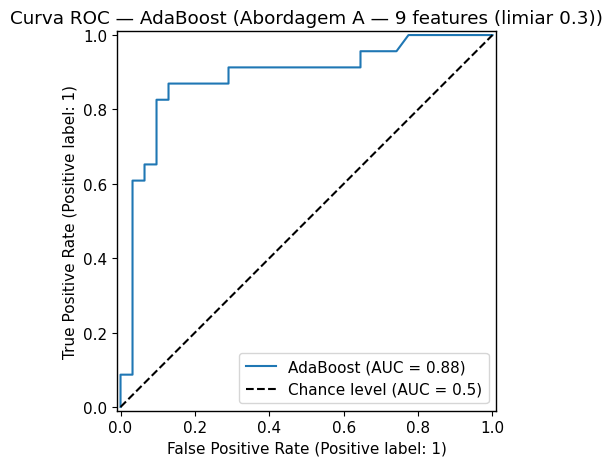


--- SVM ---
              precision    recall  f1-score   support

   Censurado       0.89      0.77      0.83        31
       Morte       0.74      0.87      0.80        23

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.83      0.81      0.82        54

AUC-ROC: 0.888


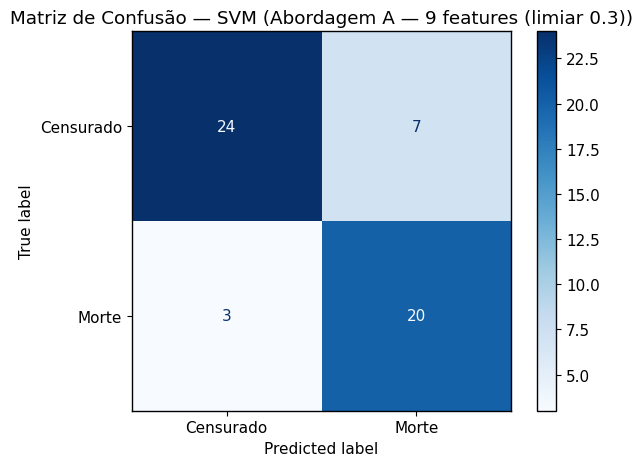

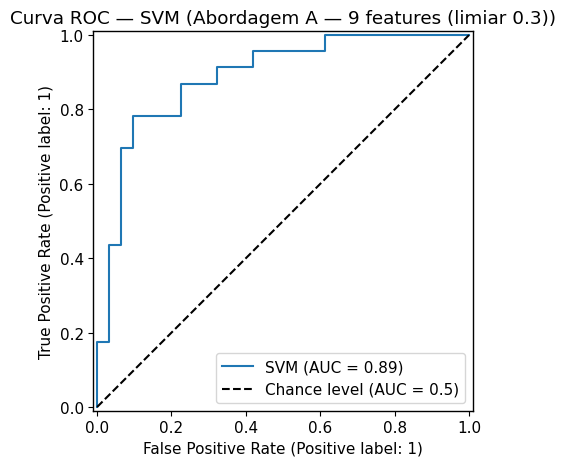


  Comparação de Modelos — Abordagem A — 9 features (limiar 0.3)
             Modelo  AUC-ROC  Precision (Morte)  Recall (Morte)  F1 (Morte)  Accuracy
Logistic Regression    0.895              0.818           0.783       0.800     0.833
                LDA    0.893              0.818           0.783       0.800     0.833
                SVM    0.888              0.741           0.870       0.800     0.815
           AdaBoost    0.884              0.800           0.870       0.833     0.852
      Random Forest    0.882              0.800           0.870       0.833     0.852
        Naive Bayes    0.881              0.895           0.739       0.810     0.852

=== Cenário 3: limiar 0.2 — 11 features ===

  Abordagem A — 11 features (limiar 0.2)

--- Logistic Regression ---
              precision    recall  f1-score   support

   Censurado       0.87      0.87      0.87        31
       Morte       0.83      0.83      0.83        23

    accuracy                           0.85        54

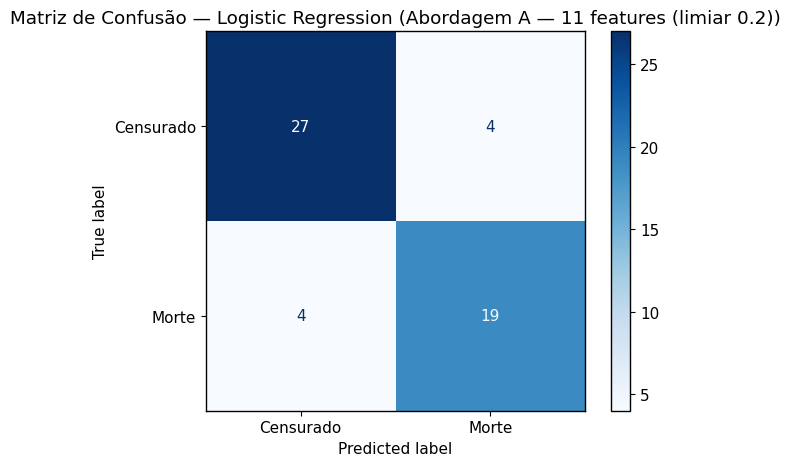

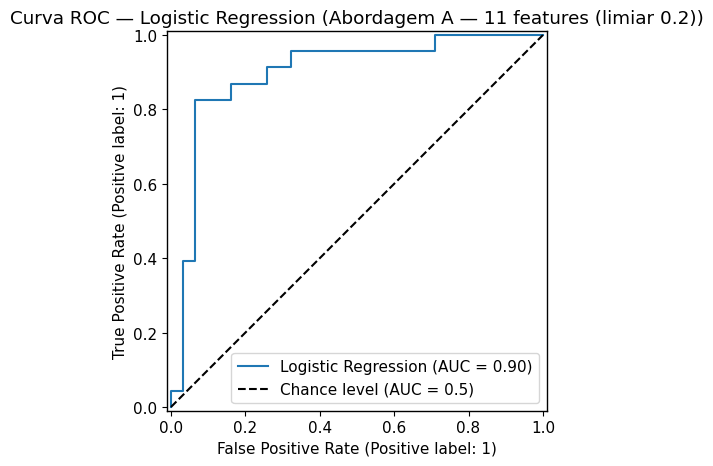


--- LDA ---
              precision    recall  f1-score   support

   Censurado       0.87      0.87      0.87        31
       Morte       0.83      0.83      0.83        23

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54

AUC-ROC: 0.893


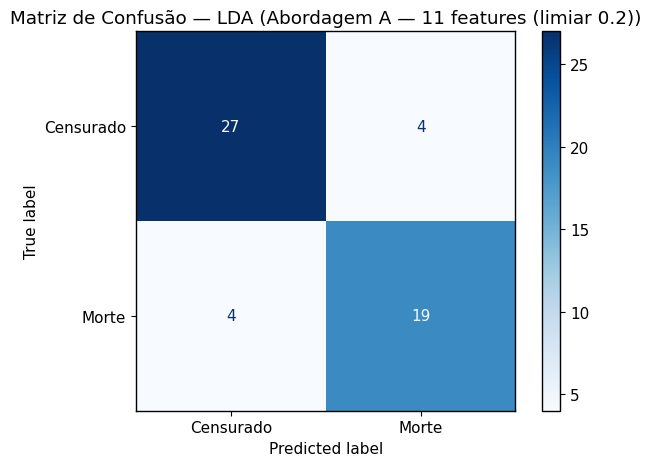

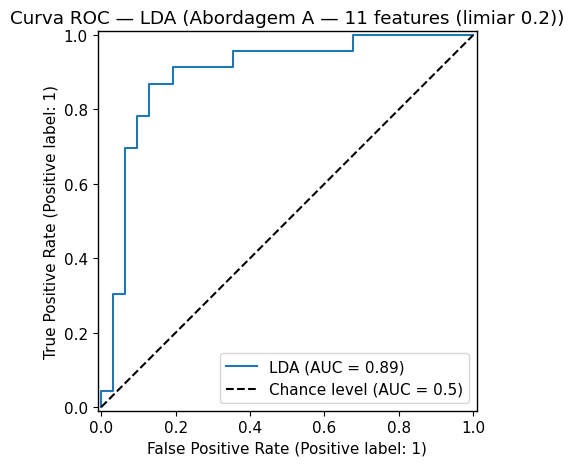


--- Naive Bayes ---
              precision    recall  f1-score   support

   Censurado       0.83      0.94      0.88        31
       Morte       0.89      0.74      0.81        23

    accuracy                           0.85        54
   macro avg       0.86      0.84      0.84        54
weighted avg       0.86      0.85      0.85        54

AUC-ROC: 0.888


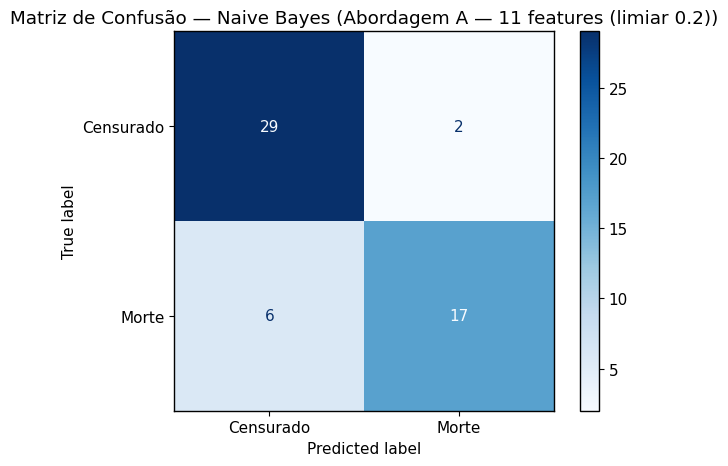

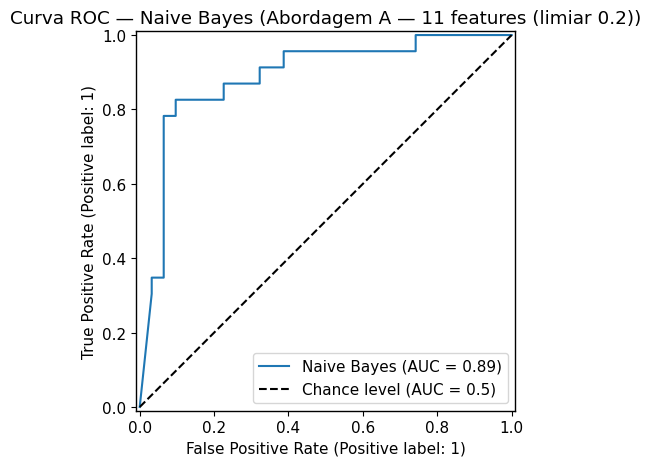


--- Random Forest ---
              precision    recall  f1-score   support

   Censurado       0.90      0.84      0.87        31
       Morte       0.80      0.87      0.83        23

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54

AUC-ROC: 0.888


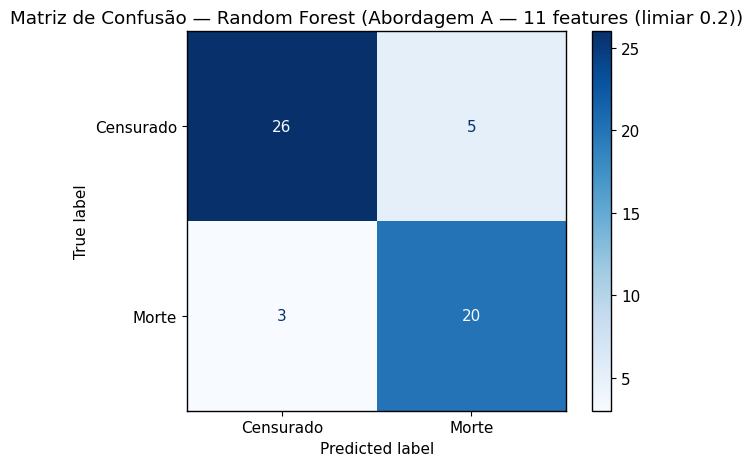

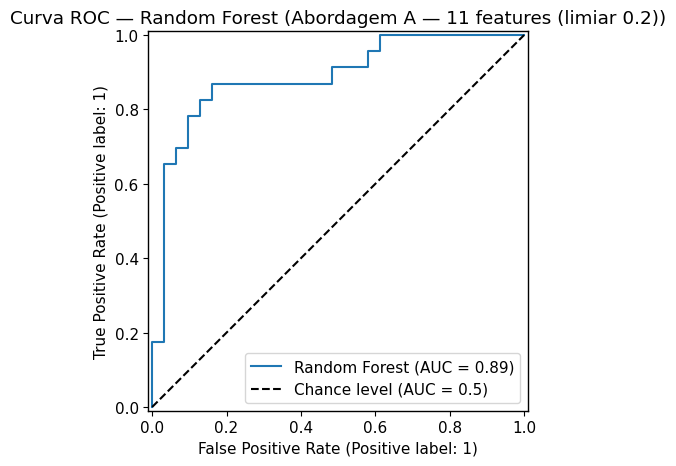


--- AdaBoost ---
              precision    recall  f1-score   support

   Censurado       0.88      0.90      0.89        31
       Morte       0.86      0.83      0.84        23

    accuracy                           0.87        54
   macro avg       0.87      0.86      0.87        54
weighted avg       0.87      0.87      0.87        54

AUC-ROC: 0.899


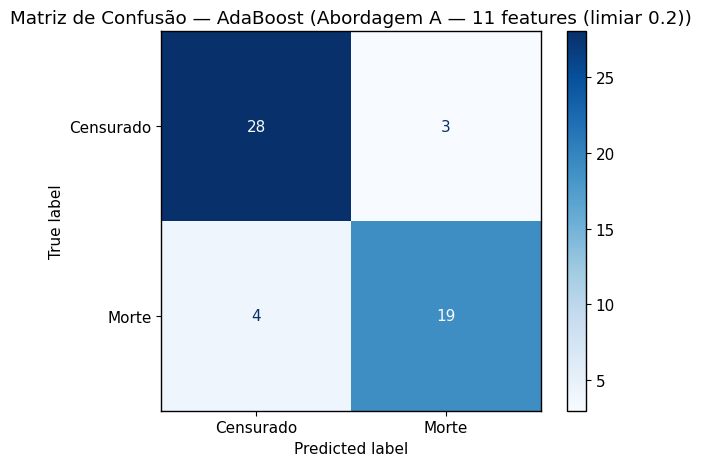

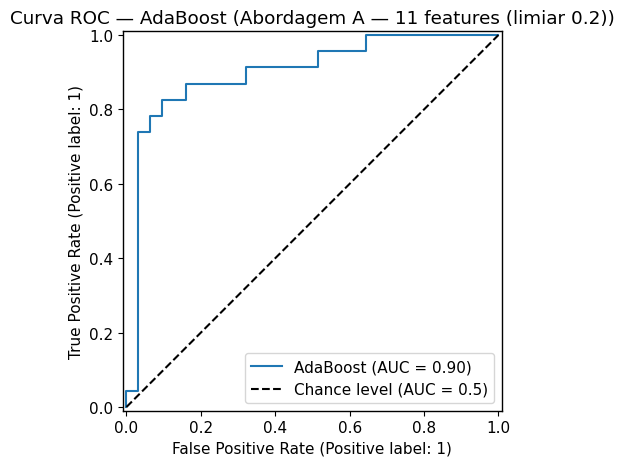


--- SVM ---
              precision    recall  f1-score   support

   Censurado       0.86      0.81      0.83        31
       Morte       0.76      0.83      0.79        23

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54

AUC-ROC: 0.910


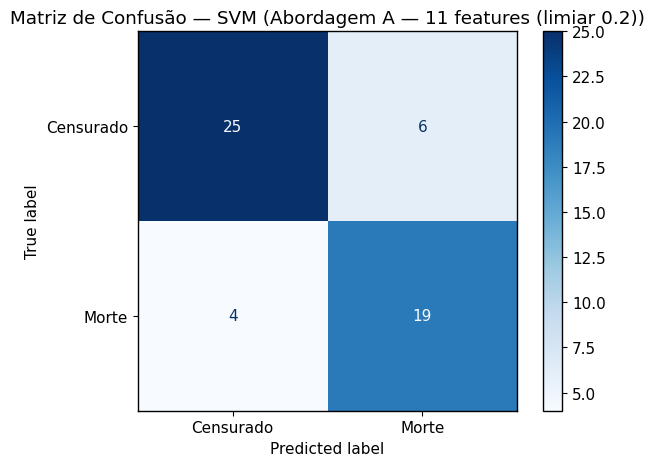

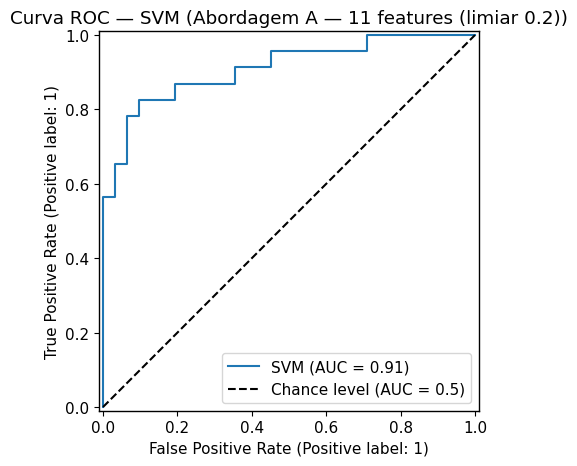


  Comparação de Modelos — Abordagem A — 11 features (limiar 0.2)
             Modelo  AUC-ROC  Precision (Morte)  Recall (Morte)  F1 (Morte)  Accuracy
                SVM    0.910              0.760           0.826       0.792     0.815
           AdaBoost    0.899              0.864           0.826       0.844     0.870
Logistic Regression    0.898              0.826           0.826       0.826     0.852
                LDA    0.893              0.826           0.826       0.826     0.852
      Random Forest    0.888              0.800           0.870       0.833     0.852
        Naive Bayes    0.888              0.895           0.739       0.810     0.852

=== Comparação dos Três Cenários ===
                              AUC-ROC                                     F1 (Morte)                                 Recall (Morte)                             
Cenário             11 features (0.2) 17 features 9 features (0.3) 11 features (0.2) 17 features 9 features (0.3) 11 features (0.2) 1

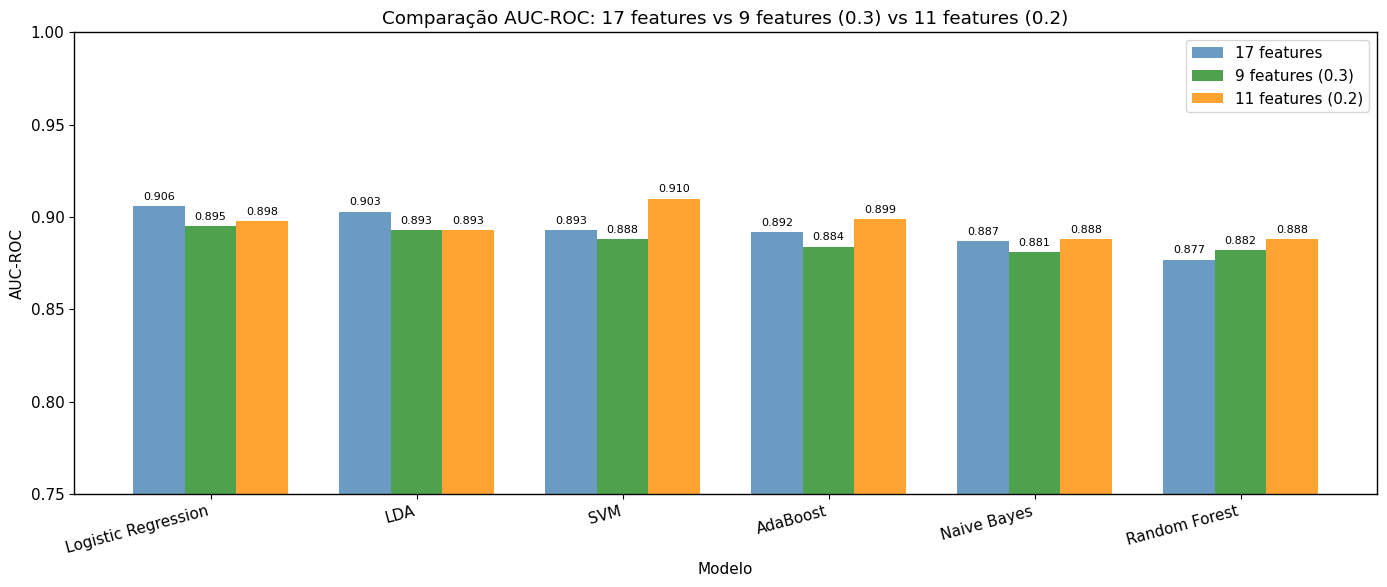


=== AUC-ROC Médio por Cenário ===
  17 features: 0.893
  9 features (0.3): 0.887
  11 features (0.2): 0.896


In [ ]:
# 10º passo: seleção de features e comparação de três cenários
# Objetivo: determinar se reduzir o número de features melhora a performance dos modelos
# Testar dois limiares de corte (0.2 e 0.3) e comparar com o cenário sem redução (17 features)

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Método 1: Teste F (ANOVA)
# Avalia se a média de cada feature é significativamente diferente entre as duas classes
# Pressupõe uma relação linear entre a feature e o target
# k='all': calcula os scores para todas as features sem eliminar nenhuma
# Usa dados de treino não normalizados porque o teste F é invariante à escala
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_A_train, y_A_train)

# Constrói um DataFrame com os scores F e p-values de cada feature
df_f = pd.DataFrame({
    'Feature': X_A_train.columns,
    'Score F': selector_f.scores_,
    'p-value': selector_f.pvalues_
}).sort_values('Score F', ascending=False).reset_index(drop=True)

# Método 2: Informação Mútua
# Mede a dependência entre cada feature e o target, incluindo relações não-lineares
# Complementa o Teste F que só captura relações lineares
# MI = 0: feature e target são independentes; MI > 0: existe dependência
selector_mi = SelectKBest(score_func=mutual_info_classif, k='all')
selector_mi.fit(X_A_train, y_A_train)

# Constrói um DataFrame com os scores de informação mútua
df_mi = pd.DataFrame({
    'Feature': X_A_train.columns,
    'Informação Mútua': selector_mi.scores_
}).sort_values('Informação Mútua', ascending=False).reset_index(drop=True)

# Método 3: Importância das Features (Random Forest)
# Mede a contribuição de cada feature para a redução da impureza de Gini
# em todas as árvores do ensemble — captura interações entre features
# n_estimators=1000: mais árvores para estimativas mais estáveis
rf_selector = RandomForestClassifier(n_estimators=1000, min_samples_leaf=5, random_state=42)
rf_selector.fit(X_A_train, y_A_train)

# Constrói um DataFrame com as importâncias de cada feature
df_rf = pd.DataFrame({
    'Feature': X_A_train.columns,
    'Importância': rf_selector.feature_importances_
}).sort_values('Importância', ascending=False).reset_index(drop=True)


# Análise conjunta dos 3 métodos

# Normaliza os scores de cada método para uma escala de 0 a 1
# dividindo cada score pelo score máximo do respetivo método
# Necessário para comparar métodos com escalas muito diferentes
df_conjunto = pd.DataFrame({'Feature': X_A_train.columns})
f_scores_norm  = df_f.set_index('Feature')['Score F']          / df_f['Score F'].max()
mi_scores_norm = df_mi.set_index('Feature')['Informação Mútua'] / df_mi['Informação Mútua'].max()
rf_scores_norm = df_rf.set_index('Feature')['Importância']      / df_rf['Importância'].max()

df_conjunto['Score F (norm)'] = df_conjunto['Feature'].map(f_scores_norm)
df_conjunto['MI (norm)']      = df_conjunto['Feature'].map(mi_scores_norm)
df_conjunto['RF (norm)']      = df_conjunto['Feature'].map(rf_scores_norm)

# Score médio dos três métodos: ranking combinado e mais robusto
# Features com score elevado nos três métodos são genuinamente relevantes
df_conjunto['Score Médio'] = df_conjunto[
    ['Score F (norm)', 'MI (norm)', 'RF (norm)']
].mean(axis=1)

# Ordena por Score Médio decrescente para ver as features mais relevantes primeiro
df_conjunto = df_conjunto.sort_values('Score Médio', ascending=False).reset_index(drop=True)

print("=== Scores combinados por feature ===")
print(df_conjunto.round(3).to_string(index=False))



# DEFINIÇÃO DOS TRÊS CENÁRIOS DE FEATURES


# Cenário 1: 17 features (todas as features originais)

# Cenário 2: limiar 0.3 (seleciona features com Score Médio >= 0.3)
# Features com score abaixo de 0.3 têm contribuição fraca nos três métodos
features_03 = df_conjunto[df_conjunto['Score Médio'] >= 0.3]['Feature'].tolist()
print(f"\nCenário 2 — Limiar 0.3: {len(features_03)} features selecionadas")
print(f"Features: {features_03}")

# Cenário 3: limiar 0.2 (seleciona features com Score Médio >= 0.2)
# Limiar mais permissivo que inclui features com contribuição moderada
features_02 = df_conjunto[df_conjunto['Score Médio'] >= 0.2]['Feature'].tolist()
print(f"\nCenário 3 — Limiar 0.2: {len(features_02)} features selecionadas")
print(f"Features: {features_02}")

# Features eliminadas em cada cenário
eliminadas_03 = df_conjunto[df_conjunto['Score Médio'] < 0.3]['Feature'].tolist()
eliminadas_02 = df_conjunto[df_conjunto['Score Médio'] < 0.2]['Feature'].tolist()
print(f"\nFeatures eliminadas pelo limiar 0.3: {eliminadas_03}")
print(f"Features eliminadas pelo limiar 0.2: {eliminadas_02}")



# Criação dos datasets para cada um dos 3 cenários

# Cenário 2: limiar 0.3

X_A_train_03 = X_A_train[features_03]
X_A_test_03  = X_A_test[features_03]

# Re-ajusta o scaler apenas às features selecionadas
# É necessário re-ajustar porque o conjunto de features mudou relativamente ao passo 8
# O scaler é ajustado (fit) apenas no treino para evitar data leakage
cols_to_scale_03 = [col for col in features_03 if col not in binary_cols]
scaler_A_03 = StandardScaler()
X_A_train_scaled_03 = X_A_train_03.copy()
X_A_test_scaled_03  = X_A_test_03.copy()
X_A_train_scaled_03[cols_to_scale_03] = scaler_A_03.fit_transform(X_A_train_03[cols_to_scale_03])
X_A_test_scaled_03[cols_to_scale_03]  = scaler_A_03.transform(X_A_test_03[cols_to_scale_03])

# Cenário 3: limiar 0.2
X_A_train_02 = X_A_train[features_02]
X_A_test_02  = X_A_test[features_02]

cols_to_scale_02 = [col for col in features_02 if col not in binary_cols]
scaler_A_02 = StandardScaler()
X_A_train_scaled_02 = X_A_train_02.copy()
X_A_test_scaled_02  = X_A_test_02.copy()
X_A_train_scaled_02[cols_to_scale_02] = scaler_A_02.fit_transform(X_A_train_02[cols_to_scale_02])
X_A_test_scaled_02[cols_to_scale_02]  = scaler_A_02.transform(X_A_test_02[cols_to_scale_02])


# Avaliação dos 6 modelos com base nos 3 cenários criados anteriormente


# Reutiliza a função treinar_e_avaliar definida no passo 9
# para avaliar os 6 modelos em cada cenário de features

# Cenário 1: 17 features
# Não é necessário re-correr, apenas adicionamos a coluna de identificação
print("\n=== Cenário 1: 17 features (sem redução) ===")
print("(Resultados já calculados no passo 9)")
resultados_A['Cenário'] = '17 features'

# Cenário 2: limiar 0.3
print(f"\n=== Cenário 2: limiar 0.3 — {len(features_03)} features ===")
resultados_03 = treinar_e_avaliar(
    X_A_train_03, X_A_test_03,
    X_A_train_scaled_03, X_A_test_scaled_03,
    y_A_train, y_A_test,
    f"Abordagem A — {len(features_03)} features (limiar 0.3)"
)
resultados_03['Cenário'] = f'{len(features_03)} features (0.3)'

# Cenário 3: limiar 0.2
print(f"\n=== Cenário 3: limiar 0.2 — {len(features_02)} features ===")
resultados_02 = treinar_e_avaliar(
    X_A_train_02, X_A_test_02,
    X_A_train_scaled_02, X_A_test_scaled_02,
    y_A_train, y_A_test,
    f"Abordagem A — {len(features_02)} features (limiar 0.2)"
)
resultados_02['Cenário'] = f'{len(features_02)} features (0.2)'



# Comparar os 3 cenários

# Junta os resultados dos três cenários num único DataFrame
comparacao_cenarios = pd.concat(
    [resultados_A, resultados_03, resultados_02],
    ignore_index=True
)

# Tabela pivot: modelos nas linhas, cenários nas colunas
# Permite comparar diretamente o impacto da redução de features em cada modelo
print("\n=== Comparação dos Três Cenários ===")
comparacao_pivot = comparacao_cenarios.pivot_table(
    index='Modelo',
    columns='Cenário',
    values=['AUC-ROC', 'Recall (Morte)', 'F1 (Morte)']
).round(3)
print(comparacao_pivot.to_string())

# Visualização comparativa do AUC-ROC nos três cenários
fig, ax = plt.subplots(figsize=(14, 6))
modelos = comparacao_cenarios['Modelo'].unique()
x = np.arange(len(modelos))
width = 0.25

# Identifica os nomes dos cenários dinamicamente
# (o número de features pode variar consoante os resultados da seleção)
cenario_17  = '17 features'
cenario_03  = f'{len(features_03)} features (0.3)'
cenario_02  = f'{len(features_02)} features (0.2)'

for i, (cenario, cor) in enumerate([
    (cenario_17,  'steelblue'),
    (cenario_03,  'forestgreen'),
    (cenario_02,  'darkorange')
]):
    dados = comparacao_cenarios[comparacao_cenarios['Cenário'] == cenario]
    dados = dados.set_index('Modelo').reindex(modelos)
    bars = ax.bar(x + i * width, dados['AUC-ROC'], width,
                  label=cenario, color=cor, alpha=0.8)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

ax.set_xlabel('Modelo')
ax.set_ylabel('AUC-ROC')
ax.set_title(f'Comparação AUC-ROC: 17 features vs {len(features_03)} features (0.3) vs {len(features_02)} features (0.2)')
ax.set_xticks(x + width)
ax.set_xticklabels(modelos, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0.75, 1.0)
plt.tight_layout()
plt.show()

# AUC-ROC médio por cenário — identifica o melhor cenário globalmente
print("\n=== AUC-ROC Médio por Cenário ===")
for cenario in [cenario_17, cenario_03, cenario_02]:
    media = comparacao_cenarios[comparacao_cenarios['Cenário'] == cenario]['AUC-ROC'].mean()
    print(f"  {cenario}: {media:.3f}")



  Otimização — 17 features

 Regressão Logística (17 features) 
Melhores hiperparâmetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
AUC-ROC na validação cruzada: 0.856
AUC-ROC no teste: 0.902
              precision    recall  f1-score   support

   Censurado       0.88      0.94      0.91        31
       Morte       0.90      0.83      0.86        23

    accuracy                           0.89        54
   macro avg       0.89      0.88      0.88        54
weighted avg       0.89      0.89      0.89        54


 LDA (17 features) 
Melhores hiperparâmetros: {'shrinkage': 0.7, 'solver': 'lsqr'}
AUC-ROC na validação cruzada: 0.856
AUC-ROC no teste: 0.902
              precision    recall  f1-score   support

   Censurado       0.87      0.87      0.87        31
       Morte       0.83      0.83      0.83        23

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54


 Ad

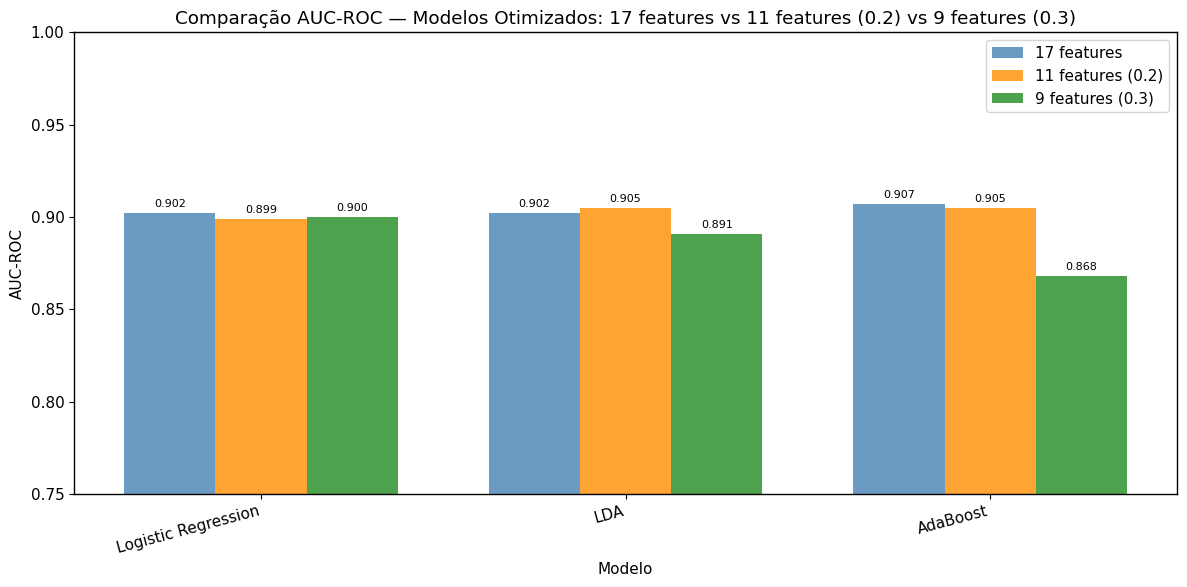


Melhor cenário identificado: 17 features (AUC-ROC médio: 0.904)

 Validação Cruzada Final (5-fold) — 17 features

 Logistic Regression 
AUC-ROC:   0.856 ± 0.079
Recall:    0.571 ± 0.054
Precision: 0.817 ± 0.082
F1:        0.671 ± 0.059
Accuracy:  0.759 ± 0.046
Diferença treino-validação AUC-ROC: 0.012 ( sem overfitting relevante)

 LDA 
AUC-ROC:   0.856 ± 0.080
Recall:    0.715 ± 0.038
Precision: 0.807 ± 0.082
F1:        0.757 ± 0.056
Accuracy:  0.802 ± 0.051
Diferença treino-validação AUC-ROC: 0.016 ( sem overfitting relevante)

 AdaBoost 
AUC-ROC:   0.841 ± 0.083
Recall:    0.726 ± 0.073
Precision: 0.807 ± 0.111
F1:        0.762 ± 0.079
Accuracy:  0.802 ± 0.076
Diferença treino-validação AUC-ROC: 0.092 ( sem overfitting relevante)

 Resumo da Validação Cruzada — 17 features 
             Modelo  AUC-ROC (CV)   Recall (CV)       F1 (CV) Accuracy (CV)  AUC-ROC (teste)
Logistic Regression 0.856 ± 0.079 0.571 ± 0.054 0.671 ± 0.059 0.759 ± 0.046            0.902
                LDA 0.856

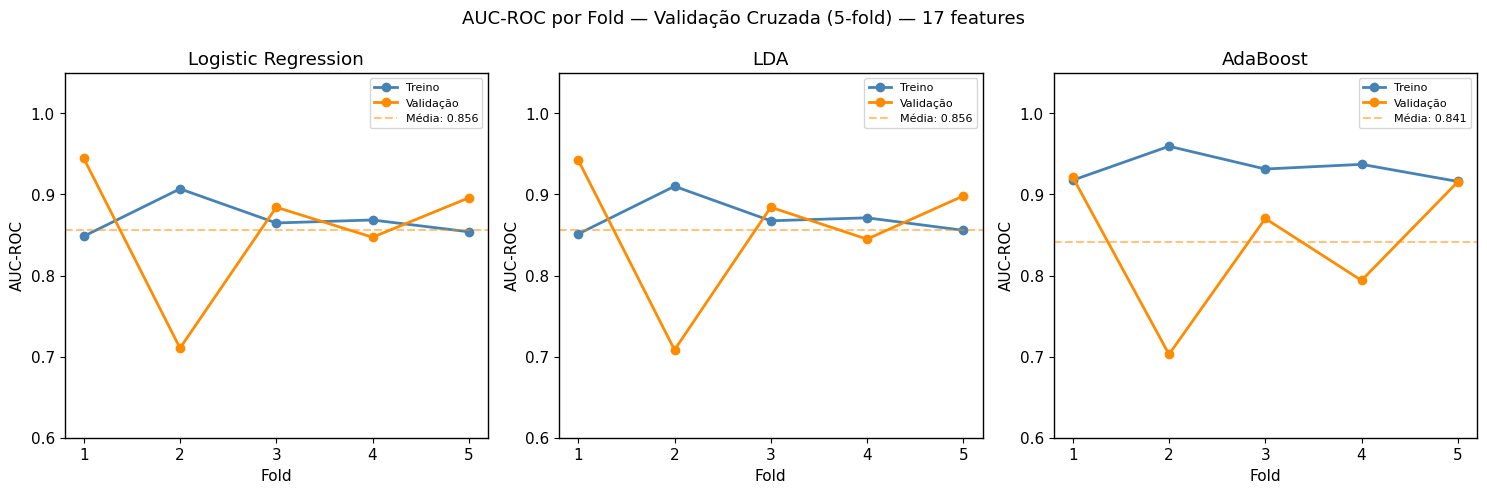

In [ ]:
# 11º passo: otimização dos 3 melhores modelos nos três cenários de features
# (17 features, limiar 0.2, limiar 0.3) e validação cruzada final

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# StratifiedKFold garante que a proporção de classes é mantida em cada fold
# n_splits=5: divide o treino em 5 folds — compromisso entre variância e viés
# shuffle=True: aleatoriza a ordem antes de dividir para evitar padrões sequenciais
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nomes dos cenários definidos dinamicamente com base no número de features
# selecionadas no passo 10, garantem consistência entre os dois passos
cenario_17 = '17 features'
cenario_02 = f'{len(features_02)} features (0.2)'
cenario_03 = f'{len(features_03)} features (0.3)'


# Grelhas de hiperparâmetros
# As grelhas são iguais para os três cenários, o que muda são os dados de entrada

# C: parâmetro de regularização inverso — valores menores = mais regularização
# penalty: L1 pode zerar coeficientes (seleção implícita); L2 penaliza coeficientes grandes
# solver: saga suporta ambas as penalizações L1 e L2
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

# solver: algoritmo para calcular os discriminantes lineares do LDA
# shrinkage: regularização da matriz de covariância
#   None: sem regularização
#   'auto': estimador de Ledoit-Wolf
#   valores numéricos: nível fixo entre 0 (sem regularização) e 1 (máximo)
param_grid_lda = {
    'solver': ['lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.1, 0.3, 0.5, 0.7]
}

# n_estimators: número de estimadores sequenciais do AdaBoost
# learning_rate: peso de cada estimador na combinação final
#   trade-off: learning_rate baixo + mais estimadores = melhor generalização mas mais lento
param_grid_ada = {
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}


# Otimização e avaliação

# Função reutilizável que otimiza os 3 modelos para um dado cenário de features
# Argumentos:
# X_train, X_test: dados não normalizados
# X_train_scaled, X_test_scaled: dados normalizados
# y_train, y_test: targets de treino e teste
# nome_cenario: string que identifica o cenário (deve corresponder ao nome definido acima)
# Devolve: DataFrame com resultados e dicionário com modelos otimizados
def otimizar_e_avaliar(X_train, X_test, X_train_scaled, X_test_scaled,
                       y_train, y_test, nome_cenario):

    print(f"\n{'='*60}")
    print(f"  Otimização — {nome_cenario}")
    print(f"{'='*60}")

    resultados = []
    modelos_otimizados = {}

    # REGRESSÃO LOGÍSTICA
    print(f"\n Regressão Logística ({nome_cenario}) ")

    # GridSearchCV testa todas as combinações da grelha com validação cruzada
    # scoring='roc_auc': otimiza o AUC-ROC — métrica mais relevante no contexto clínico
    # refit=True: re-treina o melhor modelo em todos os dados de treino após a pesquisa
    # n_jobs=-1: paraleliza usando todos os núcleos do processador disponíveis
    grid_lr = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        param_grid_lr,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        refit=True
    )
    # Regressão Logística é sensível à escala — usa dados normalizados
    grid_lr.fit(X_train_scaled, y_train)

    print(f"Melhores hiperparâmetros: {grid_lr.best_params_}")
    print(f"AUC-ROC na validação cruzada: {grid_lr.best_score_:.3f}")

    # Avalia o modelo otimizado no conjunto de teste
    # O conjunto de teste nunca foi usado durante a otimização — avaliação final imparcial
    y_prob_lr = grid_lr.best_estimator_.predict_proba(X_test_scaled)[:, 1]
    y_pred_lr = grid_lr.best_estimator_.predict(X_test_scaled)
    auc_lr = roc_auc_score(y_test, y_prob_lr)
    print(f"AUC-ROC no teste: {auc_lr:.3f}")
    print(classification_report(y_test, y_pred_lr, target_names=['Censurado', 'Morte']))

    # Guarda o modelo otimizado e o flag scaled para uso na validação cruzada
    modelos_otimizados['Logistic Regression'] = (grid_lr.best_estimator_, True)

    rd = classification_report(y_test, y_pred_lr,
                                target_names=['Censurado', 'Morte'], output_dict=True)
    resultados.append({
        'Modelo': 'Logistic Regression',
        'Cenário': nome_cenario,
        'AUC-ROC': round(auc_lr, 3),
        'Precision (Morte)': round(rd['Morte']['precision'], 3),
        'Recall (Morte)':    round(rd['Morte']['recall'], 3),
        'F1 (Morte)':        round(rd['Morte']['f1-score'], 3),
        'Accuracy':          round(rd['accuracy'], 3)
    })

    # LDA
    print(f"\n LDA ({nome_cenario}) ")

    grid_lda = GridSearchCV(
        LinearDiscriminantAnalysis(),
        param_grid_lda,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        refit=True
    )
    # LDA beneficia de dados normalizados
    grid_lda.fit(X_train_scaled, y_train)

    print(f"Melhores hiperparâmetros: {grid_lda.best_params_}")
    print(f"AUC-ROC na validação cruzada: {grid_lda.best_score_:.3f}")

    y_prob_lda = grid_lda.best_estimator_.predict_proba(X_test_scaled)[:, 1]
    y_pred_lda = grid_lda.best_estimator_.predict(X_test_scaled)
    auc_lda = roc_auc_score(y_test, y_prob_lda)
    print(f"AUC-ROC no teste: {auc_lda:.3f}")
    print(classification_report(y_test, y_pred_lda, target_names=['Censurado', 'Morte']))

    modelos_otimizados['LDA'] = (grid_lda.best_estimator_, True)

    rd = classification_report(y_test, y_pred_lda,
                                target_names=['Censurado', 'Morte'], output_dict=True)
    resultados.append({
        'Modelo': 'LDA',
        'Cenário': nome_cenario,
        'AUC-ROC': round(auc_lda, 3),
        'Precision (Morte)': round(rd['Morte']['precision'], 3),
        'Recall (Morte)':    round(rd['Morte']['recall'], 3),
        'F1 (Morte)':        round(rd['Morte']['f1-score'], 3),
        'Accuracy':          round(rd['accuracy'], 3)
    })

    # ADABOOST
    print(f"\n AdaBoost ({nome_cenario}) ")

    grid_ada = GridSearchCV(
        AdaBoostClassifier(random_state=42),
        param_grid_ada,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        refit=True
    )
    # AdaBoost é invariante à escala — usa dados não normalizados
    grid_ada.fit(X_train, y_train)

    print(f"Melhores hiperparâmetros: {grid_ada.best_params_}")
    print(f"AUC-ROC na validação cruzada: {grid_ada.best_score_:.3f}")

    y_prob_ada = grid_ada.best_estimator_.predict_proba(X_test)[:, 1]
    y_pred_ada = grid_ada.best_estimator_.predict(X_test)
    auc_ada = roc_auc_score(y_test, y_prob_ada)
    print(f"AUC-ROC no teste: {auc_ada:.3f}")
    print(classification_report(y_test, y_pred_ada, target_names=['Censurado', 'Morte']))

    modelos_otimizados['AdaBoost'] = (grid_ada.best_estimator_, False)

    rd = classification_report(y_test, y_pred_ada,
                                target_names=['Censurado', 'Morte'], output_dict=True)
    resultados.append({
        'Modelo': 'AdaBoost',
        'Cenário': nome_cenario,
        'AUC-ROC': round(auc_ada, 3),
        'Precision (Morte)': round(rd['Morte']['precision'], 3),
        'Recall (Morte)':    round(rd['Morte']['recall'], 3),
        'F1 (Morte)':        round(rd['Morte']['f1-score'], 3),
        'Accuracy':          round(rd['accuracy'], 3)
    })

    return pd.DataFrame(resultados), modelos_otimizados


# Otimização para os 3 cenários

# Cenário 1: 17 features (dataset completo, sem redução)
# Datasets criados no passo 7 (divisão treino/teste) e passo 8 (normalização)
resultados_17, modelos_17 = otimizar_e_avaliar(
    X_A_train, X_A_test,
    X_A_train_scaled, X_A_test_scaled,
    y_A_train, y_A_test,
    cenario_17
)

# Cenário 2: features selecionadas pelo limiar 0.2
# Datasets criados no passo 10 (seleção de features)
resultados_opt_02, modelos_02 = otimizar_e_avaliar(
    X_A_train_02, X_A_test_02,
    X_A_train_scaled_02, X_A_test_scaled_02,
    y_A_train, y_A_test,
    cenario_02
)

# Cenário 3: features selecionadas pelo limiar 0.3
# Datasets criados no passo 10 (seleção de features)
resultados_opt_03, modelos_03 = otimizar_e_avaliar(
    X_A_train_03, X_A_test_03,
    X_A_train_scaled_03, X_A_test_scaled_03,
    y_A_train, y_A_test,
    cenario_03
)



# Comparar os 3 cenários

# Junta os resultados dos três cenários num único DataFrame para comparação
df_todos = pd.concat([resultados_17, resultados_opt_02, resultados_opt_03],
                      ignore_index=True)

# Tabela pivot: modelos nas linhas, cenários nas colunas
# Permite comparar diretamente o impacto do número de features em cada modelo
print("\n=== Comparação Completa: modelos otimizados nos três cenários ===")
comparacao_pivot = df_todos.pivot_table(
    index='Modelo',
    columns='Cenário',
    values=['AUC-ROC', 'Recall (Morte)', 'Precision (Morte)', 'F1 (Morte)', 'Accuracy']
).round(3)
print(comparacao_pivot.to_string())

# AUC-ROC médio por cenário — identifica o melhor cenário globalmente
print("\n=== AUC-ROC Médio por Cenário (modelos otimizados) ===")
for cenario in [cenario_17, cenario_02, cenario_03]:
    media = df_todos[df_todos['Cenário'] == cenario]['AUC-ROC'].mean()
    print(f"  {cenario}: {media:.3f}")

# Visualização comparativa do AUC-ROC nos três cenários
fig, ax = plt.subplots(figsize=(12, 6))
modelos_lista = df_todos['Modelo'].unique()
x = np.arange(len(modelos_lista))
width = 0.25

# Uma barra por cenário, três barras por modelo
for i, (cenario, cor) in enumerate([
    (cenario_17, 'steelblue'),
    (cenario_02, 'darkorange'),
    (cenario_03, 'forestgreen')
]):
    dados = df_todos[df_todos['Cenário'] == cenario].set_index('Modelo').reindex(modelos_lista)
    bars = ax.bar(x + i * width, dados['AUC-ROC'], width,
                  label=cenario, color=cor, alpha=0.8)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

ax.set_xlabel('Modelo')
ax.set_ylabel('AUC-ROC')
ax.set_title(f'Comparação AUC-ROC — Modelos Otimizados: {cenario_17} vs {cenario_02} vs {cenario_03}')
ax.set_xticks(x + width)
ax.set_xticklabels(modelos_lista, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0.75, 1.0)
plt.tight_layout()
plt.show()



# Validação cruzada


# Identifica automaticamente o melhor cenário com base no AUC-ROC médio
# O melhor cenário é o que apresenta maior AUC-ROC médio nos três modelos
medias = {
    cenario_17: resultados_17['AUC-ROC'].mean(),
    cenario_02: resultados_opt_02['AUC-ROC'].mean(),
    cenario_03: resultados_opt_03['AUC-ROC'].mean()
}
melhor_cenario = max(medias, key=medias.get)
print(f"\nMelhor cenário identificado: {melhor_cenario} "
      f"(AUC-ROC médio: {medias[melhor_cenario]:.3f})")

# Seleciona os modelos e datasets correspondentes ao melhor cenário
# para usar na validação cruzada
if melhor_cenario == cenario_17:
    modelos_cv  = modelos_17
    X_tr_cv     = X_A_train_scaled   # Normalizado — para LR e LDA
    X_tr_cv_raw = X_A_train          # Não normalizado — para AdaBoost
    X_te_cv     = X_A_test_scaled
    X_te_cv_raw = X_A_test
elif melhor_cenario == cenario_02:
    modelos_cv  = modelos_02
    X_tr_cv     = X_A_train_scaled_02
    X_tr_cv_raw = X_A_train_02
    X_te_cv     = X_A_test_scaled_02
    X_te_cv_raw = X_A_test_02
else:
    modelos_cv  = modelos_03
    X_tr_cv     = X_A_train_scaled_03
    X_tr_cv_raw = X_A_train_03
    X_te_cv     = X_A_test_scaled_03
    X_te_cv_raw = X_A_test_03

print(f"\n Validação Cruzada Final (5-fold) — {melhor_cenario}")

resultados_cv = []

for nome_modelo, (modelo, scaled) in modelos_cv.items():

    # Seleciona os dados corretos consoante a sensibilidade do modelo à escala
    X_tr = X_tr_cv     if scaled else X_tr_cv_raw
    X_te = X_te_cv     if scaled else X_te_cv_raw

    # cross_validate() divide X_tr em 5 folds e avalia em cada um
    # scoring: lista de métricas calculadas em cada fold
    # return_train_score=True: calcula scores no treino para detetar overfitting
    # overfitting: diferença treino-validação > 0.1 é sinal de alerta
    cv_results = cross_validate(
        modelo, X_tr, y_A_train,
        cv=cv,
        scoring=['roc_auc', 'recall', 'precision', 'f1', 'accuracy'],
        return_train_score=True,
        n_jobs=-1
    )

    print(f"\n {nome_modelo} ")
    print(f"AUC-ROC:   {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}")
    print(f"Recall:    {cv_results['test_recall'].mean():.3f} ± {cv_results['test_recall'].std():.3f}")
    print(f"Precision: {cv_results['test_precision'].mean():.3f} ± {cv_results['test_precision'].std():.3f}")
    print(f"F1:        {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}")
    print(f"Accuracy:  {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")

    # Diferença entre score de treino e validação
    # Valores > 0.1 podem indicar overfitting — o modelo memoriza o treino
    # mas não generaliza bem para dados novos
    diff_auc = cv_results['train_roc_auc'].mean() - cv_results['test_roc_auc'].mean()
    print(f"Diferença treino-validação AUC-ROC: {diff_auc:.3f} ", end="")
    print("(possível overfitting)" if diff_auc > 0.1 else "( sem overfitting relevante)")

    resultados_cv.append({
        'Modelo':          nome_modelo,
        'AUC-ROC (CV)':    f"{cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}",
        'Recall (CV)':     f"{cv_results['test_recall'].mean():.3f} ± {cv_results['test_recall'].std():.3f}",
        'F1 (CV)':         f"{cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}",
        'Accuracy (CV)':   f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        'AUC-ROC (teste)': round(roc_auc_score(y_A_test, modelo.predict_proba(X_te)[:, 1]), 3)
    })

# Tabela resumo da validação cruzada
print(f"\n Resumo da Validação Cruzada — {melhor_cenario} ")
df_cv = pd.DataFrame(resultados_cv)
print(df_cv.to_string(index=False))

# Visualização: AUC-ROC de treino e validação por fold para cada modelo
# Permite detetar visualmente overfitting (linhas muito afastadas)
# e instabilidade (linha de validação muito irregular)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (nome_modelo, (modelo, scaled)) in zip(axes, modelos_cv.items()):
    X_tr = X_tr_cv if scaled else X_tr_cv_raw
    cv_results = cross_validate(
        modelo, X_tr, y_A_train,
        cv=cv, scoring='roc_auc',
        return_train_score=True
    )
    folds = range(1, 6)
    # Linha de treino: AUC-ROC em cada fold de treino
    ax.plot(folds, cv_results['train_score'], 'o-',
            color='steelblue', label='Treino', linewidth=2)
    # Linha de validação: AUC-ROC em cada fold de validação
    ax.plot(folds, cv_results['test_score'], 'o-',
            color='darkorange', label='Validação', linewidth=2)
    # Linha horizontal com a média de validação para referência visual
    ax.axhline(cv_results['test_score'].mean(), color='darkorange',
               linestyle='--', alpha=0.5,
               label=f"Média: {cv_results['test_score'].mean():.3f}")
    ax.set_title(nome_modelo)
    ax.set_xlabel('Fold')
    ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0.6, 1.05)
    ax.legend(fontsize=8)
    ax.set_xticks(folds)

plt.suptitle(f'AUC-ROC por Fold — Validação Cruzada (5-fold) — {melhor_cenario}',
             fontsize=13)
plt.tight_layout()
plt.show()

 Modelo AdaBoost treinado com sucesso.
  Observações de treino: 212
  Features: 17
  Hiperparâmetros: n_estimators=50, learning_rate=0.5

 Relatório de Classificação — AdaBoost Final
              precision    recall  f1-score   support

   Censurado       0.88      0.90      0.89        31
       Morte       0.86      0.83      0.84        23

    accuracy                           0.87        54
   macro avg       0.87      0.86      0.87        54
weighted avg       0.87      0.87      0.87        54

AUC-ROC: 0.907


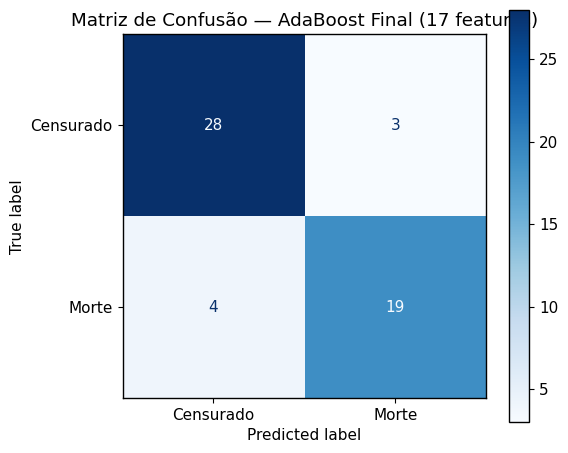


Interpretação da Matriz de Confusão:
  Verdadeiros Negativos (VN): 28 — censurados corretamente identificados
  Falsos Positivos (FP):      3 — censurados classificados como morte
  Falsos Negativos (FN):      4 — mortes não identificadas (erro mais grave)
  Verdadeiros Positivos (VP): 19 — mortes corretamente identificadas

  Sensibilidade (Recall): 0.826 — 19 de 23 mortes identificadas
  Especificidade:         0.903 — 28 de 31 censurados identificados


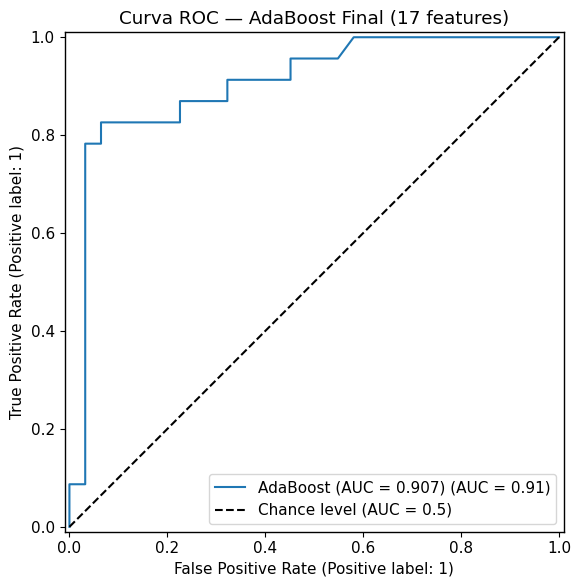


=== Importância das Features — AdaBoost Final ===
       Feature  Importância  Importância Acumulada
     Ascites_Y     0.244962                  0.245
        Copper     0.165464                  0.410
     Bilirubin     0.150095                  0.561
   Prothrombin     0.143783                  0.704
           Age     0.104984                  0.809
      Alk_Phos     0.091225                  0.901
 Tryglicerides     0.038076                  0.939
          SGOT     0.031358                  0.970
   Cholesterol     0.030054                  1.000
     Platelets     0.000000                  1.000
       Albumin     0.000000                  1.000
         Stage     0.000000                  1.000
  Drug_Placebo     0.000000                  1.000
Hepatomegaly_Y     0.000000                  1.000
     Spiders_Y     0.000000                  1.000
         Sex_M     0.000000                  1.000
     Edema_num     0.000000                  1.000


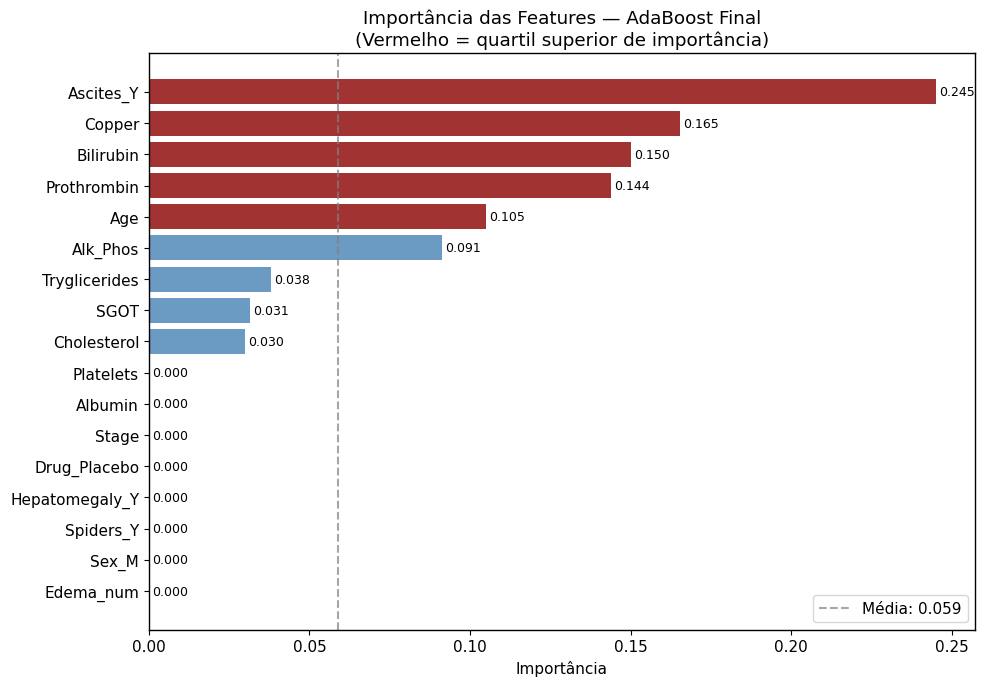


Features no quartil superior de importância (≥ 0.105):
  Ascites_Y: 0.245 (importância acumulada até aqui: 0.245)
  Copper: 0.165 (importância acumulada até aqui: 0.410)
  Bilirubin: 0.150 (importância acumulada até aqui: 0.561)
  Prothrombin: 0.144 (importância acumulada até aqui: 0.704)
  Age: 0.105 (importância acumulada até aqui: 0.809)

 Resumo Final do Modelo AdaBoost
  Modelo  Features  n_estimators  learning_rate  AUC-ROC  Precision (Morte)  Recall (Morte)  F1 (Morte)  Accuracy  Sensibilidade  Especificidade
AdaBoost        17            50            0.5    0.907              0.864           0.826       0.844      0.87          0.826           0.903


In [ ]:
# 12º passo: treino final e avaliação definitiva do modelo AdaBoost
# com os melhores hiperparâmetros encontrados pela GridSearchCV (passo 11)
# usando as 17 features e os dados de treino completos

from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Modelo Final

# n_estimators=50: número reduzido de estimadores sequenciais. A GridSearchCV encontrou que modelos mais simples generalizam melhor neste dataset
# learning_rate=0.5: peso moderado de cada estimador na combinação final serve para equilibrar a velocidade de aprendizagem e capacidade de generalização
# random_state=42: garante reprodutibilidade dos resultados
modelo_final = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=0.5,
    random_state=42
)


# Treino do modelo final


# O modelo é treinado com os dados de treino disponíveis (212 observações)
# AdaBoost é invariante à escala, ou seja, usa dados não normalizados
modelo_final.fit(X_A_train, y_A_train)

print(" Modelo AdaBoost treinado com sucesso.")
print(f"  Observações de treino: {X_A_train.shape[0]}")
print(f"  Features: {X_A_train.shape[1]}")
print(f"  Hiperparâmetros: n_estimators=50, learning_rate=0.5")


# Avaliação do modelo com dados de teste
# O conjunto de teste (X_A_test, y_A_test) representa dados completamente novos para o modelo, nunca foi usado durante o treino nem durante a otimização de hiperparâmetros
# Esta é a avaliação final e definitiva da capacidade preditiva do modelo

# .predict() aplica o modelo treinado aos dados de teste e devolve a classe prevista (0 = censurado, 1 = morte) para cada uma das 54 observações de teste
y_pred_final = modelo_final.predict(X_A_test)

# .predict_proba() devolve a probabilidade de pertencer a cada classe para cada observação — uma matriz de shape (54, 2)
# [:, 1] seleciona a coluna das probabilidades da classe positiva (morte = 1. Necessário para calcular o AUC-ROC e a curva ROC
y_prob_final = modelo_final.predict_proba(X_A_test)[:, 1]

# AUC-ROC
# 0.5 = classificador aleatório; 1.0 = classificador perfeito
auc_final = roc_auc_score(y_A_test, y_prob_final)

# Report de avaliação
# Precisão, Recall, Score F1 e support
print("\n Relatório de Classificação — AdaBoost Final")
print(classification_report(y_A_test, y_pred_final,
                             target_names=['Censurado', 'Morte']))
print(f"AUC-ROC: {auc_final:.3f}")

# Matriz de confusão
cm = confusion_matrix(y_A_test, y_pred_final)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Censurado', 'Morte']
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusão — AdaBoost Final (17 features)')
plt.tight_layout()
plt.show()

# Extrai os valores da matriz de confusão para interpretação clínica
vn, fp, fn, vp = cm.ravel()
print(f"\nInterpretação da Matriz de Confusão:")
print(f"  Verdadeiros Negativos (VN): {vn} — censurados corretamente identificados")
print(f"  Falsos Positivos (FP):      {fp} — censurados classificados como morte")
print(f"  Falsos Negativos (FN):      {fn} — mortes não identificadas (erro mais grave)")
print(f"  Verdadeiros Positivos (VP): {vp} — mortes corretamente identificadas")
print(f"\n  Sensibilidade (Recall): {vp/(vp+fn):.3f} — {vp} de {vp+fn} mortes identificadas")
print(f"  Especificidade:         {vn/(vn+fp):.3f} — {vn} de {vn+fp} censurados identificados")

#Curva ROC
# A linha diagonal representa um classificador aleatório (AUC = 0.5)
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_A_test, y_prob_final,
    name=f'AdaBoost (AUC = {auc_final:.3f})',
    plot_chance_level=True,
    ax=ax
)
ax.set_title('Curva ROC — AdaBoost Final (17 features)')
plt.tight_layout()
plt.show()



#  Importância das features


# O AdaBoost calcula a importância de cada feature com base na frequência com que é usada para fazer divisões nas árvores simples (stumps) e na redução do erro que essas divisões provocam
# feature_importances_ devolve um array com a importância de cada feature
# Os valores somam 1 (são proporções da importância total)
importancias = modelo_final.feature_importances_

# Constrói um DataFrame com as importâncias ordenadas de forma decrescente
df_importancias = pd.DataFrame({
    'Feature': X_A_train.columns,
    'Importância': importancias
}).sort_values('Importância', ascending=False).reset_index(drop=True)

# Adiciona a importância acumulada para perceber quantas features são necessárias para explicar X% da importância total
df_importancias['Importância Acumulada'] = df_importancias['Importância'].cumsum().round(3)

print("\n=== Importância das Features — AdaBoost Final ===")
print(df_importancias.to_string(index=False))

# Visualização gráfica das importâncias
fig, ax = plt.subplots(figsize=(10, 7))
cores = ['darkred' if imp >= df_importancias['Importância'].quantile(0.75)
         else 'steelblue' for imp in df_importancias['Importância']]
ax.barh(df_importancias['Feature'], df_importancias['Importância'],
        color=cores, alpha=0.8)

# Adiciona os valores de importância no fim de cada barra
for i, (imp, feat) in enumerate(zip(df_importancias['Importância'],
                                     df_importancias['Feature'])):
    ax.text(imp + 0.001, i, f'{imp:.3f}', va='center', fontsize=9)

# Linha vertical na média das importâncias para referência
media_imp = df_importancias['Importância'].mean()
ax.axvline(x=media_imp, color='gray', linestyle='--', alpha=0.7,
           label=f'Média: {media_imp:.3f}')

ax.set_xlabel('Importância')
ax.set_title('Importância das Features — AdaBoost Final\n'
             '(Vermelho = quartil superior de importância)')
ax.invert_yaxis()  # Feature mais importante no topo
ax.legend()
plt.tight_layout()
plt.show()

# Resumo das features mais importantes
print(f"\nFeatures no quartil superior de importância (≥ {df_importancias['Importância'].quantile(0.75):.3f}):")
top_features = df_importancias[
    df_importancias['Importância'] >= df_importancias['Importância'].quantile(0.75)
]
for _, row in top_features.iterrows():
    print(f"  {row['Feature']}: {row['Importância']:.3f} "
          f"(importância acumulada até aqui: {row['Importância Acumulada']:.3f})")



# Resumo final
report_dict = classification_report(y_A_test, y_pred_final,
                                     target_names=['Censurado', 'Morte'],
                                     output_dict=True)

df_resumo = pd.DataFrame([{
    'Modelo': 'AdaBoost',
    'Features': 17,
    'n_estimators': 50,
    'learning_rate': 0.5,
    'AUC-ROC': round(auc_final, 3),
    'Precision (Morte)': round(report_dict['Morte']['precision'], 3),
    'Recall (Morte)':    round(report_dict['Morte']['recall'], 3),
    'F1 (Morte)':        round(report_dict['Morte']['f1-score'], 3),
    'Accuracy':          round(report_dict['accuracy'], 3),
    'Sensibilidade':     round(vp/(vp+fn), 3),
    'Especificidade':    round(vn/(vn+fp), 3)
}])

print("\n Resumo Final do Modelo AdaBoost")
print(df_resumo.to_string(index=False))

In [ ]:
# Cálculo do Intervalo de Confiança 95% do AUC-ROC por bootstrap

import numpy as np
from sklearn.metrics import roc_auc_score

# Probabilidades previstas pelo modelo final (já calculadas no passo do treino final)
# y_prob_final = modelo_final.predict_proba(X_A_test)[:, 1]  # já existe no teu notebook

n_bootstraps = 2000
rng = np.random.RandomState(42)  # garante reprodutibilidade
bootstrapped_scores = []

y_test_array = np.array(y_A_test)

for i in range(n_bootstraps):
    # Reamostragem com reposição dos índices do conjunto de teste
    indices = rng.randint(0, len(y_prob_final), len(y_prob_final))

    # Garante que a reamostragem contém as duas classes (necessário para calcular AUC-ROC)
    if len(np.unique(y_test_array[indices])) < 2:
        continue

    score = roc_auc_score(y_test_array[indices], y_prob_final[indices])
    bootstrapped_scores.append(score)

# Ordena os scores para extrair os percentis 2.5 e 97.5 (IC 95%)
sorted_scores = np.sort(bootstrapped_scores)
ic_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ic_upper = sorted_scores[int(0.975 * len(sorted_scores))]

print(f"AUC-ROC: {roc_auc_score(y_test_array, y_prob_final):.3f}")
print(f"IC 95% (bootstrap, {len(bootstrapped_scores)} reamostragens válidas): "
      f"[{ic_lower:.3f}, {ic_upper:.3f}]")

AUC-ROC: 0.907
IC 95% (bootstrap, 2000 reamostragens válidas): [0.812, 0.982]


/tmp/ipykernel_2211/534570366.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


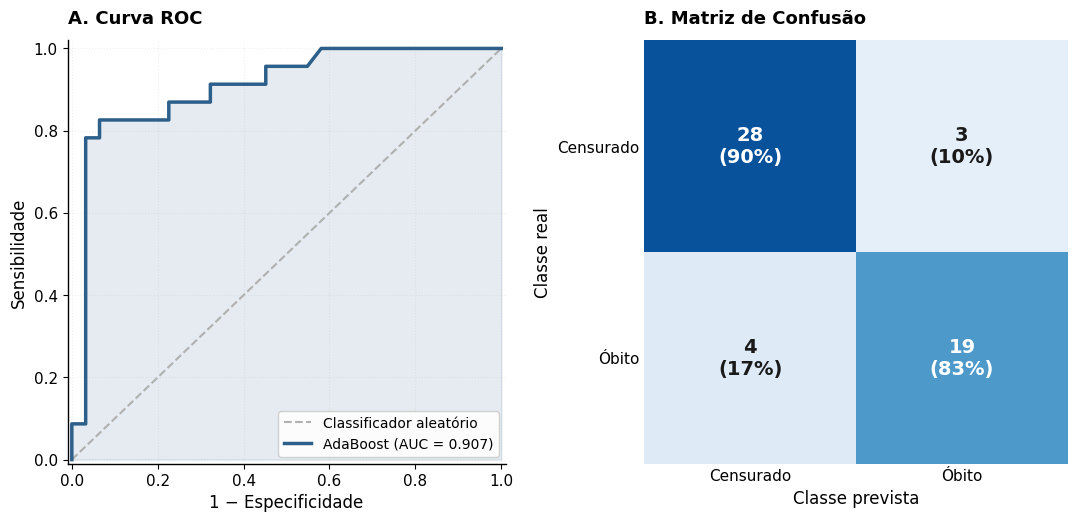

Figura 1 guardada como 'figura1_roc_matriz_confusao.png' e '.pdf'


In [ ]:
# Figura 1: Curva ROC + Matriz de Confusão (painéis A e B)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc, confusion_matrix
import numpy as np

# Estilo visual mais cuidado para publicação
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.0

# Recalcula a curva ROC a partir das probabilidades já obtidas no modelo final
# y_A_test e y_prob_final já existem no teu notebook (passo do treino final)
fpr, tpr, _ = roc_curve(y_A_test, y_prob_final)
roc_auc = auc(fpr, tpr)

# Cria a figura com 2 painéis lado a lado
fig = plt.figure(figsize=(13, 5.5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

# ============================================================
# PAINEL A — Curva ROC
# ============================================================
ax1 = fig.add_subplot(gs[0])

# Linha de referência (classificador aleatório)
ax1.plot([0, 1], [0, 1], linestyle='--', color='#B0B0B0', linewidth=1.5,
          label='Classificador aleatório')

# Curva ROC com preenchimento sob a curva
ax1.plot(fpr, tpr, color='#2C5F8A', linewidth=2.5,
          label=f'AdaBoost (AUC = {roc_auc:.3f})')
ax1.fill_between(fpr, tpr, alpha=0.12, color='#2C5F8A')

ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.02])
ax1.set_xlabel('1 − Especificidade', fontsize=12, fontweight='medium')
ax1.set_ylabel('Sensibilidade', fontsize=12, fontweight='medium')
ax1.set_title('A. Curva ROC', fontsize=13, fontweight='bold', loc='left', pad=12)
ax1.legend(loc='lower right', fontsize=10, frameon=True, framealpha=0.9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.2, linestyle=':')

# ============================================================
# PAINEL B — Matriz de Confusão
# ============================================================
ax2 = fig.add_subplot(gs[1])

cm = confusion_matrix(y_A_test, y_pred_final)
labels = ['Censurado', 'Óbito']

# Heatmap manual com anotações claras
im = ax2.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max() * 1.15)

# Anota cada célula com o valor absoluto e a percentagem por linha
for i in range(2):
    for j in range(2):
        valor = cm[i, j]
        pct = valor / cm[i].sum() * 100
        cor_texto = 'white' if valor > cm.max() * 0.5 else '#1a1a1a'
        ax2.text(j, i, f'{valor}\n({pct:.0f}%)',
                  ha='center', va='center', fontsize=14,
                  color=cor_texto, fontweight='bold')

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_yticklabels(labels, fontsize=11)
ax2.set_xlabel('Classe prevista', fontsize=12, fontweight='medium')
ax2.set_ylabel('Classe real', fontsize=12, fontweight='medium')
ax2.set_title('B. Matriz de Confusão', fontsize=13, fontweight='bold', loc='left', pad=12)

# Remove ticks desnecessários
ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# Exporta em alta resolução (300 dpi, adequado para publicação)
plt.savefig('figura1_roc_matriz_confusao.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.savefig('figura1_roc_matriz_confusao.pdf', bbox_inches='tight',
            facecolor='white')  # versão vetorial, ideal para LaTeX/Word
plt.show()

print("Figura 1 guardada como 'figura1_roc_matriz_confusao.png' e '.pdf'")

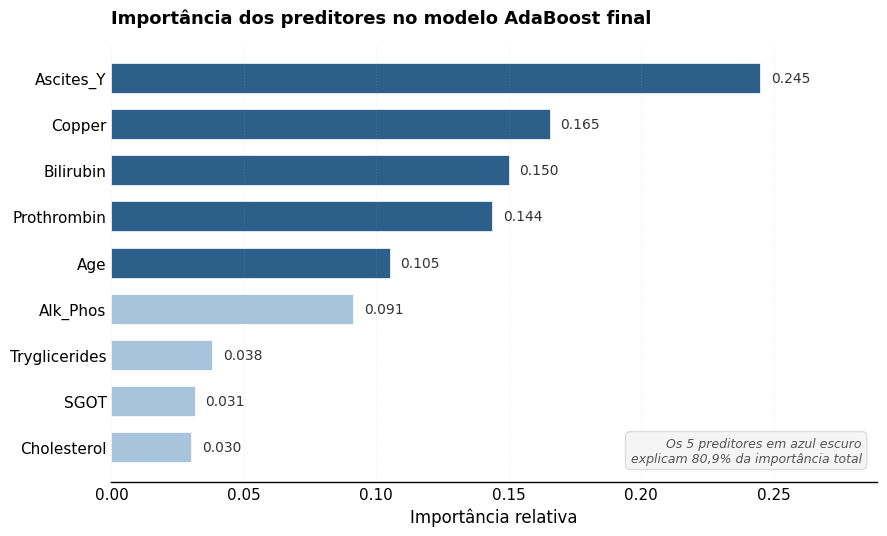

Figura 2 guardada como 'figura2_importancia_features.png' e '.pdf'


In [ ]:
# Figura 2: Importância das Features (AdaBoost)

import matplotlib.pyplot as plt
import pandas as pd

# df_importancias já existe no teu notebook (passo de avaliação do modelo final)
# Filtra apenas as features com importância > 0 para não poluir o gráfico
df_plot = df_importancias[df_importancias['Importância'] > 0].copy()
df_plot = df_plot.sort_values('Importância', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Define cores: destaque para o top-5 (que explica ~81% da importância)
n_top = 5
cores = ['#2C5F8A' if i >= len(df_plot) - n_top else '#A8C4DC'
         for i in range(len(df_plot))]

bars = ax.barh(df_plot['Feature'], df_plot['Importância'],
                color=cores, edgecolor='white', linewidth=0.5, height=0.65)

# Anota o valor no fim de cada barra
for bar, valor in zip(bars, df_plot['Importância']):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
             f'{valor:.3f}', va='center', fontsize=10, color='#333333')

ax.set_xlabel('Importância relativa', fontsize=12, fontweight='medium')
ax.set_title('Importância dos preditores no modelo AdaBoost final',
              fontsize=13, fontweight='bold', loc='left', pad=14)
ax.set_xlim(0, df_plot['Importância'].max() * 1.18)

# Remove molduras desnecessárias
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(length=0, labelsize=11)
ax.grid(axis='x', alpha=0.2, linestyle=':')

# Legenda informal através de texto
ax.text(0.98, 0.04, 'Os 5 preditores em azul escuro\nexplicam 80,9% da importância total',
         transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
         style='italic', color='#555555',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5', edgecolor='#DDDDDD'))

plt.tight_layout()

plt.savefig('figura2_importancia_features.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.savefig('figura2_importancia_features.pdf', bbox_inches='tight',
            facecolor='white')
plt.show()

print("Figura 2 guardada como 'figura2_importancia_features.png' e '.pdf'")

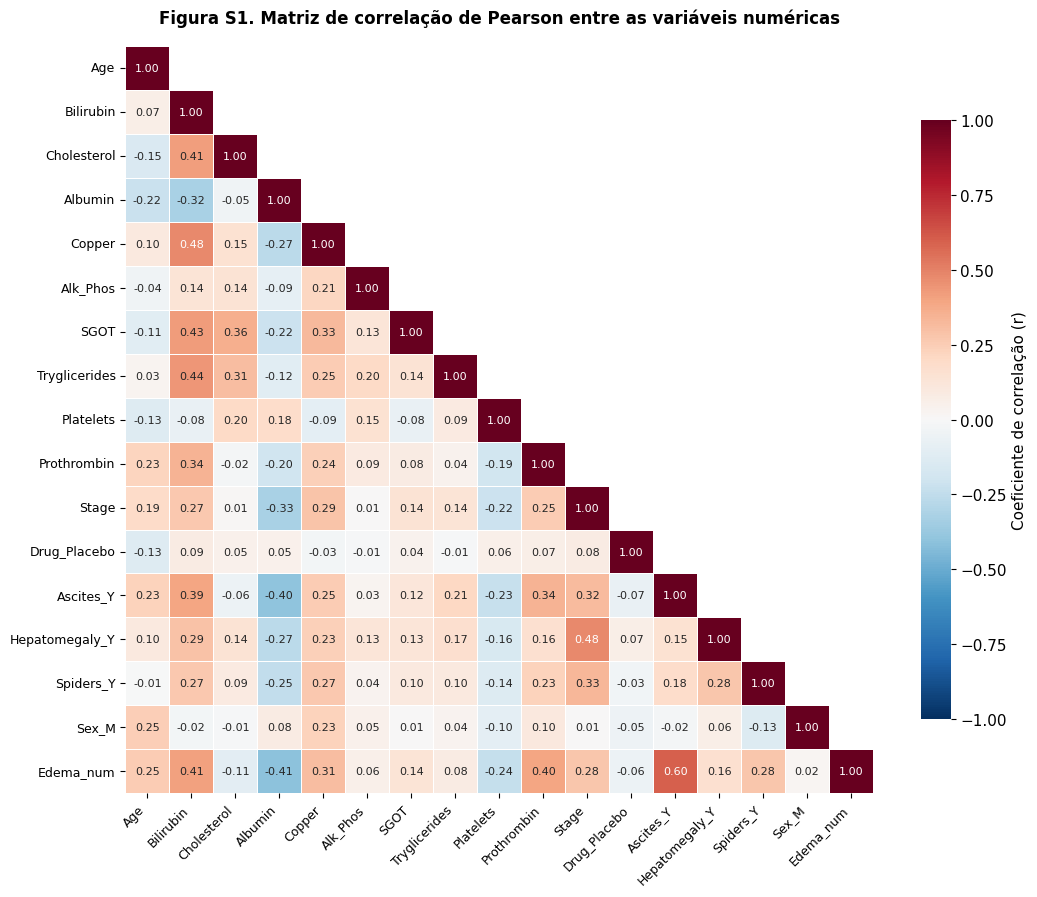

Figura S1 guardada como 'figuraS1_matriz_correlacao.png' e '.pdf'


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 9))

# Recalcula a matriz de correlação, pois 'db2' foi definida localmente na função anterior
db2 = X_A.corr()

mask = np.triu(np.ones_like(db2, dtype=bool), k=1)  # esconde o triângulo superior (redundante)

sns.heatmap(db2, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.6,
            linecolor='white', cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlação (r)'},
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Figura S1. Matriz de correlação de Pearson entre as variáveis numéricas',
              fontsize=12, fontweight='bold', pad=16)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('figuraS1_matriz_correlacao.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.savefig('figuraS1_matriz_correlacao.pdf', bbox_inches='tight',
            facecolor='white')
plt.show()

print("Figura S1 guardada como 'figuraS1_matriz_correlacao.png' e '.pdf'")

In [ ]:
# ============================================================================
# CÁLCULO DO C-INDEX PARA O MODELO ADABOOST FINAL (AUC = 0.907)
# ============================================================================

# O modelo final já está treinado como 'modelo_final'
# As probabilidades já foram calculadas como 'y_prob_final'
# Os valores reais estão em 'y_A_test'

# 1. Instalar lifelines se necessário (descomente se não tiver instalado)
!pip install lifelines

from lifelines.utils import concordance_index
from sklearn.metrics import roc_auc_score

# 2. Calcular C-index usando a função concordance_index do lifelines
c_index_final = concordance_index(y_A_test, y_prob_final)

# 3. Verificar com AUC-ROC (para confirmação)
auc_check = roc_auc_score(y_A_test, y_prob_final)

print("\n" + "="*60)
print("C-INDEX DO MODELO ADABOOST FINAL")
print("="*60)
print(f"C-index (índice de concordância): {c_index_final:.3f}")
print(f"AUC-ROC (para comparação):        {auc_check:.3f}")
print("="*60)

# 4. Interpretação clínica do C-index
print("\n📊 Interpretação do C-index:")
if c_index_final >= 0.9:
    print("  ✅ Excelente capacidade discriminativa")
    print("     O modelo distingue muito bem entre pacientes que vão falecer e os que vão sobreviver")
elif c_index_final >= 0.8:
    print("  ✅ Bom poder preditivo")
    print("     O modelo tem boa capacidade de discriminação clínica")
elif c_index_final >= 0.7:
    print("  ⚠️  Capacidade discriminativa razoável")
    print("     O modelo pode ser útil, mas com limitações")
elif c_index_final >= 0.6:
    print("  ⚠️  Capacidade discriminativa moderada")
    print("     O modelo tem utilidade limitada para decisões clínicas")
else:
    print("  ❌ Capacidade discriminativa fraca")
    print("     O modelo não é melhor que o acaso")

# 5. Verificação da equivalência C-index ≈ AUC-ROC
diferenca = abs(c_index_final - auc_check)
print(f"\n🔍 Verificação: C-index ({c_index_final:.3f}) ≈ AUC-ROC ({auc_check:.3f})")
print(f"   Diferença: {diferenca:.4f} (deve ser praticamente zero)")
if diferenca < 0.001:
    print("   ✅ Os valores são equivalentes, como esperado para classificação binária")
else:
    print("   ⚠️  Os valores diferem ligeiramente (verificar cálculos)")

# 6. Resumo para comparação com outros estudos
print("\n" + "="*60)
print("RESULTADO PARA COMPARAÇÃO COM OUTROS ESTUDOS")
print("="*60)
print(f"Modelo:          AdaBoost")
print(f"Hiperparâmetros: n_estimators=50, learning_rate=0.5")
print(f"Features:        17")
print(f"Dataset:         Abordagem A (sem CL)")
print(f"N (treino):      {X_A_train.shape[0]}")
print(f"N (teste):       {X_A_test.shape[0]}")
print(f"C-index:         {c_index_final:.3f}")
print(f"AUC-ROC:         {auc_check:.3f}")
print("="*60)

# 7. Opcional: intervalo de confiança bootstrap para o C-index
# (útil para artigos científicos - descomente se quiser)
"""
import numpy as np
from sklearn.utils import resample

def bootstrap_c_index(y_true, y_pred, n_bootstrap=1000):
    c_indices = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = resample(range(n), n_samples=n, replace=True)
        c_idx = concordance_index(y_true[idx], y_pred[idx])
        c_indices.append(c_idx)

    ci_lower = np.percentile(c_indices, 2.5)
    ci_upper = np.percentile(c_indices, 97.5)
    return ci_lower, ci_upper

ci_lower, ci_upper = bootstrap_c_index(y_A_test, y_prob_final)
print(f"\nIC 95% do C-index (bootstrap): {ci_lower:.3f} - {ci_upper:.3f}")
"""

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 1.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=a84602a3570b9c681acd584efd6e0014aaa64306ef4e85bac6c321c20ca10832
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma

C-INDEX DO MODELO ADABOOST FINAL
C-index (índice de concordância): 0.907
AUC-ROC (para comparação):        0.907

📊 Interpretação do C-index:
  ✅ Excelente capacidade discriminativa
     O modelo distingue muito bem entre pacientes que vão falecer e os que vão sobreviver

🔍 Verificação: C-index (0.907) ≈ AUC-ROC (0.907)
   Diferença: 0.0000 (deve ser praticamente zero)
   ✅ Os valores são equivalentes, como esperado para classificação binária

RESULTADO PARA COMPARAÇÃO COM OUTROS ESTUDOS

'\nimport numpy as np\nfrom sklearn.utils import resample\n\ndef bootstrap_c_index(y_true, y_pred, n_bootstrap=1000):\n    c_indices = []\n    n = len(y_true)\n    for _ in range(n_bootstrap):\n        idx = resample(range(n), n_samples=n, replace=True)\n        c_idx = concordance_index(y_true[idx], y_pred[idx])\n        c_indices.append(c_idx)\n\n    ci_lower = np.percentile(c_indices, 2.5)\n    ci_upper = np.percentile(c_indices, 97.5)\n    return ci_lower, ci_upper\n\nci_lower, ci_upper = bootstrap_c_index(y_A_test, y_prob_final)\nprint(f"\nIC 95% do C-index (bootstrap): {ci_lower:.3f} - {ci_upper:.3f}")\n'